In [11]:
import os
import sys
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
from scipy.stats import wasserstein_distance
from scipy.stats import chi2 as chi2_stat
import yaml
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
import torch
import pyhf

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
import polars as pl

# Force CPU (Prevents PyTorch pin_memory CUDA crashes)
os.environ["CUDA_VISIBLE_DEVICES"] = ""

# Adjust to your setup
helpers_path = os.path.join('/home/aegis/Titan1/NRAD/data/model_scripts')
sys.path.insert(0, os.path.abspath(helpers_path))
from Classifier import Classifier

import joblib

# Load the exact scaler used during dataset preparation
scaler_path = "Final_Dataset_ATLAS/minmax_scaler.joblib" # Update path if needed
scaler = joblib.load(scaler_path)

# Ensure the feature list matches exactly what was used for the scaler
features_to_scale = ['met_recalc_pt', 'ht', 'mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32']

In [12]:
# Options and Parameters

LUMI = 25.3845 # fb^-1
N_GEN_SIG = 100_000

SIGNAL_DIR = "/home/aegis/ether/Research_HEP/NRAD/Signal/replicate_atlas"
# SIGNAL_DIR = "/home/aegis/Titan0/madgraph/MG5_aMC_v3_7_0/bin/ttbar_validation/Events/Analysis_Output_ver2"
SCALER_PATH = "Final_Dataset_ATLAS/minmax_scaler.joblib"
CONFIG_PATH = "/home/aegis/Titan1/NRAD/data/configs/bc_discrim.yml"

SIG_COLS = [
    "pT_j1", "eta_j1", "phi_j1", "pT_j2", "eta_j2", "phi_j2", "m_jj", "sm_jj", 
    "tau21_j1", "tau21_j2", "tau32_j1", "tau32_j2", "met", "phi_met", 
    "min_dPhi", "ht", "pt_balance", "delta_phi_j1j2", "weight"
]

METADATA_LIST = [
    {"Mass": 1000, "Rinv": 2, "XS": 9551.0, "TheoryUnc": 0.52},
    {"Mass": 1000, "Rinv": 4, "XS": 9540.0, "TheoryUnc": 0.52},
    {"Mass": 1000, "Rinv": 6, "XS": 9552.0, "TheoryUnc": 0.52},
    {"Mass": 1000, "Rinv": 8, "XS": 9554.0, "TheoryUnc": 0.52},
    {"Mass": 2000, "Rinv": 2, "XS": 146.3, "TheoryUnc": 0.53},
    {"Mass": 2000, "Rinv": 4, "XS": 146.8, "TheoryUnc": 0.53},
    {"Mass": 2000, "Rinv": 6, "XS": 146.1, "TheoryUnc": 0.53},
    {"Mass": 2000, "Rinv": 8, "XS": 145.3, "TheoryUnc": 0.53},
    {"Mass": 3000, "Rinv": 2, "XS": 14.24, "TheoryUnc": 0.48},
    {"Mass": 3000, "Rinv": 4, "XS": 14.20, "TheoryUnc": 0.48},
    {"Mass": 3000, "Rinv": 6, "XS": 14.21, "TheoryUnc": 0.48},
    {"Mass": 3000, "Rinv": 8, "XS": 14.26, "TheoryUnc": 0.48},
]
DF_META = pd.DataFrame(METADATA_LIST)

DEVICE = "cpu"

In [13]:
# Functions
def plot_sr_signal_separated(
    mode_label: str, 
    df_bkg: pl.DataFrame, 
    df_data: pl.DataFrame, 
    df_signal: pl.DataFrame, 
    feature: str, 
    bkg_label: str = "Extrapolated Bkg",
    bkg_weight_col: str = "extrapolated_SR_weight",
    signal_label: str = "Signal", 
    force_log: bool = False
):
    plt.rcParams.update({
        'font.size': 14, 'axes.labelsize': 16, 'xtick.labelsize': 14, 'ytick.labelsize': 14,
        'legend.fontsize': 12, 'lines.linewidth': 1.5, 'xtick.direction': 'in', 'ytick.direction': 'in',
        'xtick.top': True, 'ytick.right': True, 'axes.formatter.use_mathtext': True, 'axes.linewidth': 1.2,
        'hatch.linewidth': 0.5
    })
    
    pretty_labels = {
        'ht': r'$H_{T}$ [GeV]', 'met_recalc_pt': r'$E_{T}^{\text{miss}}$ [GeV]', 'met': r'$E_{T}^{\text{miss}}$ [GeV]', 
        'mjj': r'$m_{jj}$ [GeV]', 'ljet1_tau21': r'Leading jet $\tau_{21}$', 'ljet1_tau32': r'Leading jet $\tau_{32}$',
        'ljet2_tau21': r'Subleading jet $\tau_{21}$', 'ljet2_tau32': r'Subleading jet $\tau_{32}$'
    }
    
    use_log = force_log or any(log_var in feature.lower() for log_var in ['ht', 'met_recalc_pt', 'met', 'mjj'])
    
    # Extract Arrays
    data_arr = df_data.get_column(feature).drop_nulls().to_numpy()
    bkg_arr = df_bkg.get_column(feature).drop_nulls().to_numpy()
    sig_arr = df_signal.get_column(feature).drop_nulls().to_numpy() if df_signal is not None else np.array([])
    
    if len(data_arr) == 0:
        print(f"Skipping {feature} - No valid observed data.")
        return
        
    # Extract Weights
    bkg_weights = df_bkg.get_column(bkg_weight_col).to_numpy()
    sig_weights = df_signal.get_column("final_weight").to_numpy() if df_signal is not None else np.array([])
    
    # Setup Figure
    fig = plt.figure(figsize=(8, 8))
    gs = gridspec.GridSpec(2, 1, height_ratios=[3.5, 1], hspace=0.08)
    ax_main = fig.add_subplot(gs[0])
    ax_ratio = fig.add_subplot(gs[1], sharex=ax_main)
    
    # Binning (based on Data and Background)
    combined_arr = np.concatenate([data_arr, bkg_arr])
    bins = np.histogram_bin_edges(combined_arr, bins=15)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    bin_widths = np.diff(bins)

    # --- 1. BACKGROUND (Filled) ---
    counts_bkg, _ = np.histogram(bkg_arr, bins=bins, weights=bkg_weights)
    sumw2_bkg, _ = np.histogram(bkg_arr, bins=bins, weights=bkg_weights**2)
    bkg_err = np.sqrt(sumw2_bkg)
    
    ax_main.hist(bkg_arr, bins=bins, weights=bkg_weights, histtype='stepfilled', 
                 color='#1f78b4', alpha=0.3, edgecolor='#1f78b4', label=bkg_label)
    
    ax_main.bar(bin_centers, 2 * bkg_err, bottom=counts_bkg - bkg_err, width=bin_widths, 
                color='none', edgecolor='gray', hatch='////', linewidth=0, alpha=0.5, zorder=5, label='Stat. Unc.')

    # --- 2. SIGNAL & BACKGROUND + SIGNAL ---
    counts_sig = np.zeros_like(counts_bkg)
    if len(sig_arr) > 0:
        counts_sig, _ = np.histogram(sig_arr, bins=bins, weights=sig_weights)
        
        # Plot Signal Only (Unstacked)
        ax_main.hist(sig_arr, bins=bins, weights=sig_weights, histtype='step', 
                     color='#ff7f0e', linewidth=2.5, label=f'{signal_label}')
        
        # Plot Background + Signal (Stacked expected yield)
        counts_bkg_sig = counts_bkg + counts_sig
        ax_main.hist(bin_centers, bins=bins, weights=counts_bkg_sig, histtype='step', 
                     color='#2ca02c', linewidth=2.0, linestyle='--', label=f'{bkg_label} + Signal')

    # --- 3. OBSERVED DATA ---
    counts_data, _ = np.histogram(data_arr, bins=bins)
    data_errors = np.sqrt(counts_data)
    ax_main.errorbar(bin_centers, counts_data, yerr=data_errors, fmt='ko', 
                     label='Observed Data', zorder=10, capsize=0, markersize=5)
    
    # --- STYLING MAIN PANEL ---
    y_max = max(np.max(counts_data) + np.max(data_errors), np.max(counts_bkg + bkg_err))
    if use_log:
        ax_main.set_yscale('log')
        ax_main.set_ylim(0.1, y_max * 1000) 
    else:
        ax_main.set_ylim(0, y_max * 1.55) 
        ax_main.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        
    ax_main.set_ylabel("Events / Bin")
    plt.setp(ax_main.get_xticklabels(), visible=False)
    
    ax_main.text(0.04, 0.94, f"{mode_label} selection\nSR Extrapolation\n" + r"$\sqrt{s} = 13$ TeV", 
                 transform=ax_main.transAxes, fontsize=14, verticalalignment='top')
                 
    # Reorder legend to ensure Data is always first
    handles, loc_labels = ax_main.get_legend_handles_labels()
    if "Observed Data" in loc_labels:
        idx = loc_labels.index("Observed Data")
        handles.insert(0, handles.pop(idx))
        loc_labels.insert(0, loc_labels.pop(idx))
    ax_main.legend(handles, loc_labels, loc='upper right', frameon=False, ncol=2)
    
    # --- RATIO PANEL ---
    with np.errstate(divide='ignore', invalid='ignore'):
        # Data / Background
        ratio_data = np.where(counts_bkg > 0, counts_data / counts_bkg, np.nan)
        rel_err_data = np.where(counts_data > 0, data_errors / counts_data, 0)
        rel_err_bkg = np.where(counts_bkg > 0, bkg_err / counts_bkg, 0)
        ratio_data_err = np.abs(ratio_data) * np.sqrt(rel_err_data**2 + rel_err_bkg**2)
        
        # (Background + Signal) / Background (Shows the expected signal bump)
        ratio_sig_bump = np.where(counts_bkg > 0, (counts_bkg + counts_sig) / counts_bkg, np.nan)

    # Uncertainty band around 1.0 (Background Stat Unc)
    ax_ratio.bar(bin_centers, 2 * rel_err_bkg, bottom=1.0 - rel_err_bkg, width=bin_widths, 
                 color='gray', hatch='////', edgecolor='none', alpha=0.3, zorder=1)
    ax_ratio.axhline(1.0, color='gray', linestyle='-', linewidth=1.0, zorder=2)
    
    # Plot Signal bump in ratio
    if len(sig_arr) > 0:
        ax_ratio.step(bins, np.append(ratio_sig_bump, ratio_sig_bump[-1]), where='post', 
                      color='#2ca02c', linestyle='--', linewidth=2)

    # Plot Data points
    ax_ratio.errorbar(bin_centers, ratio_data, yerr=ratio_data_err, fmt='ko', capsize=0, markersize=5, zorder=10)
    
    ax_ratio.set_xlabel(pretty_labels.get(feature, feature))
    ax_ratio.set_ylabel("Ratio to Bkg")
    ax_ratio.set_ylim(0.5, 1.5)
    ax_ratio.set_yticks([0.75, 1.0, 1.25])
    
    fig.align_ylabels((ax_main, ax_ratio))
    
    # os.makedirs("Extrapolation_Plots", exist_ok=True)
    # plt.savefig(f"Bkg_Sig_plots/SR_{mode_label}_{feature}.pdf", bbox_inches='tight')
    plt.show()
    plt.close(fig)

def unscale_dataframe(df: pl.DataFrame, fitted_scaler, features: list) -> pl.DataFrame:
    """
    Inverse transforms scaled columns back to physical units for plotting.
    """
    # Extract the scaled features
    X_scaled = df.select(features).to_numpy()
    
    # Reverse the scaling back to physical values
    X_physical = fitted_scaler.inverse_transform(X_scaled)
    
    # Safely overwrite the columns in a new Polars DataFrame
    unscaled_series = [pl.Series(name=f, values=X_physical[:, i]) for i, f in enumerate(features)]
    return df.with_columns(unscaled_series)

def get_metadata(mode):
    """Retrieves XS and Theory Uncertainty based on mode string."""
    try:
        parts = mode.split('_')
        mass, rinv = int(parts[0]), int(parts[1])
        row = DF_META[(DF_META['Mass'] == mass) & (DF_META['Rinv'] == rinv)]
        return row.iloc[0]['XS'], row.iloc[0]['TheoryUnc']
    except (IndexError, ValueError):
        print(f"Warning: Metadata not found for {mode}")
        return 1.0, 0.0

def load_signal_for_cwola(mode_str, base_path=SIGNAL_DIR):
    """
    Loads a signal mode, calculates physical weights, renames columns to match CWoLa framework,
    and returns a Polars DataFrame.
    """
    file_path = os.path.join(base_path, f"{mode_str}_events_markXI.txt")
    
    if not os.path.exists(file_path):
        print(f"Error: Signal file {file_path} not found.")
        return None
        
    print(f"Loading Signal: {mode_str}...")
    
    # 1. Read using Pandas to cleanly handle arbitrary whitespace (\s+)
    df_sim = pd.read_csv(file_path, sep='\s+', names=SIG_COLS, skiprows=1)
    
    # 2. Calculate Physical Weights
    xs_eff, theory_unc = get_metadata(mode_str)
    norm_factor = (xs_eff * LUMI) / N_GEN_SIG
    
    # Notice we overwrite the raw Pythia 'weight' column with our normalized weight
    df_sim['weight'] = norm_factor
    
    # 3. Rename columns to map directly to your SR data features
    rename_mapping = {
        "m_jj": "mjj",
        "tau21_j1": "ljet1_tau21",
        "tau32_j1": "ljet1_tau32",
        "tau21_j2": "ljet2_tau21",
        "tau32_j2": "ljet2_tau32",
        "met": "met_recalc_pt", # Or keep "met" if your main SR data uses "met" instead
        "weight": "final_weight"
    }
    df_sim = df_sim.rename(columns=rename_mapping)
    
    # 4. Convert to Polars DataFrame to match your df_mc and df_data
    df_signal = pl.from_pandas(df_sim)
    
    print(f"  -> Loaded {len(df_signal)} generated events.")
    print(f"  -> Total expected yield (Lumi = {LUMI} fb^-1): {df_signal['final_weight'].sum():.2f} events.")
    
    return df_signal

# def load_signal_parquet_cwola(mode_str, region="SR", base_path=SIGNAL_DIR):
#     """
#     Loads a signal mode from the Awkward/Parquet pipeline, calculates physical weights, 
#     renames columns to match CWoLa framework, and returns a Polars DataFrame.
#     """
#     # 1. Format file path based on your new saving script's naming convention
#     tag = f"bsm_{mode_str}_pu_run2"
#     file_path = os.path.join(base_path, region, f"{tag}.parquet")
    
#     if not os.path.exists(file_path):
#         print(f"Error: Signal file {file_path} not found.")
#         return None
        
#     print(f"Loading Signal: {mode_str} (Region: {region})...")
    
#     # 2. Read directly using Polars. 
#     # We only select the 1D scalar columns we need for ML, ignoring jagged/nested arrays like jet_pt
#     desired_cols = [
#         "tau21_j1", "tau32_j1", "tau21_j2", "tau32_j2", 
#         "ht", "met_recalc_pt", "mjj"
#     ]
    
#     # Load and subset the columns (ignores columns that don't exist yet, like m_jj)
#     df_signal = pl.read_parquet(file_path)
#     available_cols = [c for c in desired_cols if c in df_signal.columns]
#     df_signal = df_signal.select(available_cols)
    
#     # 3. Calculate Physical Weights
#     xs_eff, theory_unc = get_metadata(mode_str)
#     norm_factor = (xs_eff * LUMI) / N_GEN_SIG
    
#     # Add the normalized weight column using Polars syntax
#     df_signal = df_signal.with_columns(pl.lit(norm_factor).alias("final_weight"))
    
#     # 4. Rename columns to map directly to your SR data features
#     rename_mapping = {
#         "tau21_j1": "ljet1_tau21",
#         "tau32_j1": "ljet1_tau32",
#         "tau21_j2": "ljet2_tau21",
#         "tau32_j2": "ljet2_tau32"
#         # "met_recalc_pt" is already correctly named in the new script
#         # NOTE: If you add "m_jj" to your processing script, add its mapping here!
#     }
    
#     # Filter the mapping to only rename columns that exist in the dataframe
#     valid_renames = {k: v for k, v in rename_mapping.items() if k in df_signal.columns}
#     df_signal = df_signal.rename(valid_renames)
    
#     print(f"  -> Loaded {len(df_signal)} surviving events.")
#     print(f"  -> Total expected yield (Lumi = {LUMI} fb^-1): {df_signal['final_weight'].sum():.2f} events.")
    
#     return df_signal

def run_ensemble_inference(X, eval_dir, code_prefix, CLASSIFIER_RUNS=20):
    all_scores = np.zeros((len(X), CLASSIFIER_RUNS))
    for i in range(CLASSIFIER_RUNS):
        model_path = os.path.join(eval_dir, f"model_{code_prefix}_run{i}.pt")
        NN = torch.load(model_path, map_location=DEVICE, weights_only=False)
        NN.model.eval()
        all_scores[:, i] = NN.evaluation(X).flatten()
    return np.median(all_scores, axis=1)

def apply_sr_cuts(df):
    return df.filter(
        (pl.col("ht") > 600) & 
        (pl.col("met_recalc_pt") > 600) & 
        (pl.col("met_recalc_pt") < 2000) & 
        (pl.col("mjj") < 10000) & 
        (pl.col("ht") < 4000)
    )

def find_optimal_cwola_cut(df_signal: pl.DataFrame, df_bkg: pl.DataFrame, score_col: str, weight_col: str = "final_weight", num_steps: int = 1000):
    # 1. Extract scores and weights, dropping nulls to prevent misalignment
    sig_arr = df_signal.select([score_col, weight_col]).drop_nulls().to_numpy()
    bkg_arr = df_bkg.select([score_col, weight_col]).drop_nulls().to_numpy()
    
    # Separate the numpy columns for easier masking
    scores_sig, weights_sig = sig_arr[:, 0], sig_arr[:, 1]
    scores_bkg, weights_bkg = bkg_arr[:, 0], bkg_arr[:, 1]
    
    # 2. Create an array of possible cut thresholds to test
    min_score = min(scores_bkg.min(), scores_sig.min())
    max_score = max(scores_bkg.max(), scores_sig.max())
    thresholds = np.linspace(min_score, max_score, num_steps)
    
    significances = []
    
    # 3. Iterate over each possible cut
    for cut in thresholds:
        # Calculate S: Sum of 'final_weight' for signal events scoring HIGHER than the cut
        S = np.sum(weights_sig[scores_sig > cut])
        
        # Calculate B: Sum of 'final_weight' for background events scoring HIGHER than the cut
        B = np.sum(weights_bkg[scores_bkg > cut])
        
        # 4. Calculate Significance
        if B > 0:
            sig = S / np.sqrt(B)
        else:
            sig = 0.0 
            
        significances.append(sig)
        
    significances = np.array(significances)
    
    # 5. Find the index of the highest significance
    best_idx = np.argmax(significances)
    
    best_cut = thresholds[best_idx]
    max_significance = significances[best_idx]
    
    return best_cut, max_significance, thresholds, significances
# --- How to use it ---
# best_cut, max_sig, thresholds, sig_curve = find_optimal_cwola_cut(scores_sig, scores_bkg)
# print(f"The optimal cut is {best_cut:.4f} yielding a significance of {max_sig:.2f}")

def plot_cwola_scores(df_data: pl.DataFrame, df_bkg: pl.DataFrame, df_signal: pl.DataFrame, score_col: str, bins: int = 50, density: bool = True):

    # 1. Extract the score columns from Polars and convert to NumPy arrays for Matplotlib
    # We drop nulls to avoid plotting errors
    scores_bkg = df_bkg.select(pl.col(score_col).drop_nulls()).to_series().to_numpy()
    scores_sig = df_signal.select(pl.col(score_col).drop_nulls()).to_series().to_numpy()
    scores_data = df_data.select(pl.col(score_col).drop_nulls()).to_series().to_numpy()

    # Determine the global min and max to ensure bins align perfectly across all three plots
    min_score = min(scores_bkg.min(), scores_sig.min(), scores_data.min())
    max_score = max(scores_bkg.max(), scores_sig.max(), scores_data.max())
    bin_edges = np.linspace(min_score, max_score, bins + 1)

    
    best_cut, max_sig, thresholds, sig_curve = find_optimal_cwola_cut(df_signal, df_bkg, score_col)
    print(f"The optimal cut is {best_cut:.4f} yielding a significance of {max_sig:.2f}")

    # best_cut = np.percentile(scores_bkg, 95)
    best_cut = find_best_cut(scores_sig)

    # 2. Set up the plot
    plt.figure(figsize=(10, 6))

    # 3. Plot Background (Filled step area)
    plt.hist(scores_bkg, bins=bin_edges, density=density, alpha=0.5, 
             color='#1f77b4', label='Background', histtype='stepfilled')

    # 4. Plot Signal (Filled step area, different color)
    plt.hist(scores_sig, bins=bin_edges, density=density, alpha=0.5, 
             color='#d62728', label='Signal', histtype='stepfilled')

    # 5. Plot Data (Points/Markers)
    # Calculate histogram values manually for data so we can plot it as scatter points
    data_counts, _ = np.histogram(scores_data, bins=bin_edges, density=density)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    plt.plot(bin_centers, data_counts, 'ko', label='Data', markersize=4)
    plt.axvline(best_cut, color='gray', linestyle='--', label=f'Best Cut({best_cut:.2f})')

    # 6. Formatting
    plt.xlabel(f'CWoLa Score ({score_col})', fontsize=12)
    ylabel = 'Density (Normalized)' if density else 'Counts / Bin'
    plt.ylabel(ylabel, fontsize=12)
    plt.title('CWoLa Classifier Score Distributions', fontsize=14)
    plt.legend(frameon=False, fontsize=11)
    
    # Optional: Log scale if background heavily dominates the low-score region
    # plt.yscale('log') 
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"CWoLa_Score_Distribution_{score_col}.pdf", bbox_inches='tight')
    plt.show()

def find_limit(scan_values, cls_values, threshold=0.05):
    cls_vals_flat = np.array([float(val) for val in cls_values])
    return np.interp(threshold, cls_vals_flat[::-1], scan_values[::-1])

import numpy as np
from sklearn.mixture import GaussianMixture

def find_best_cut(data):
    """
    Finds the optimal threshold to separate a bimodal distribution 
    using a 2-component Gaussian Mixture Model.
    """
    # 1. Reshape data for sklearn (needs 2D array)
    X = data.reshape(-1, 1)
    
    # 2. Fit the GMM
    gmm = GaussianMixture(n_components=2, random_state=42).fit(X)
    
    # 3. Extract parameters
    means = gmm.means_.flatten()
    stds = np.sqrt(gmm.covariances_.flatten())
    weights = gmm.weights_
    
    # Sort them so we know which is left and which is right
    idx = np.argsort(means)
    m1, m2 = means[idx]
    s1, s2 = stds[idx]
    w1, w2 = weights[idx]
    
    # 4. Solve for the intersection of the two Gaussians
    # This uses the quadratic formula derived from setting the two PDFs equal
    A = 1/(2*s1**2) - 1/(2*s2**2)
    B = m2/(s2**2) - m1/(s1**2)
    C = m1**2/(2*s1**2) - m2**2/(2*s2**2) - np.log((w1*s2)/(w2*s1))
    
    roots = np.roots([A, B, C])
    
    # 5. Select the root that lies between the two means
    cut_point = [r for r in roots if m1 < r < m2]
    
    return cut_point[0] if cut_point else (m1 + m2) / 2

In [15]:
# Definitions

# context_var = ['ht', 'met_recalc_pt']
context_var = ['met_recalc_pt', 'ht']
features = ['mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32']
variables = context_var + features

MJJ_BINS = np.linspace(1000, 4000, 31)


SIGNAL_MODES = [
    # "1000_2",
    # "1000_4",
    "1000_6",
    "1000_8",
    # "2000_2",
    "2000_4",
    "2000_6",
    # "2000_8",
    "3000_2",
    "3000_4",
    # "3000_6",
    # "3000_8"
]

# selection = "ML" # or ML
# bkg_type = "Nom" # Nom

# if bkg_type == "Extrap":
#     bkg_weight_col = "extrapolated_SR_weight"
# elif bkg_type == "Nom":
#     bkg_weight_col = "final_weight"

# results = []

Loading MC and Data in SR datasets...
MC and Data are loaded sucessfully
MC events: 528846, Data events: 188757
MC columns: ['mc_process', 'subprocess', 'raw_weights', 'weight_sub', 'met_recalc_pt', 'met_recalc_phi', 'ht', 'mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32', 'crossSection_pb', 'genFiltEff', 'kFactor', 'sumOfWeights', 'sum_w_pros', 'scale_factor_sub_weight', 'luminosity', 'official_scale_factor', 'final_weight', 'crossSection_pb_right', 'genFiltEff_right', 'kFactor_right', 'sumOfWeights_right', 'sum_w_pros_right', 'scale_factor_sub_weight_right', 'luminosity_right', 'ml_extrapolation_weight', 'extrapolated_SR_weight']
Data columns: ['met_recalc_pt', 'met_recalc_phi', 'ht', 'mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32']
Unscaling MC and Data for plotting...
Running background inference...

Processing Signal Mode: 1000_6...
Loading Signal: 1000_6...
  -> Loaded 13013 generated events.
  -> Total expected yield (Lumi = 25.3845 fb^-1): 3155

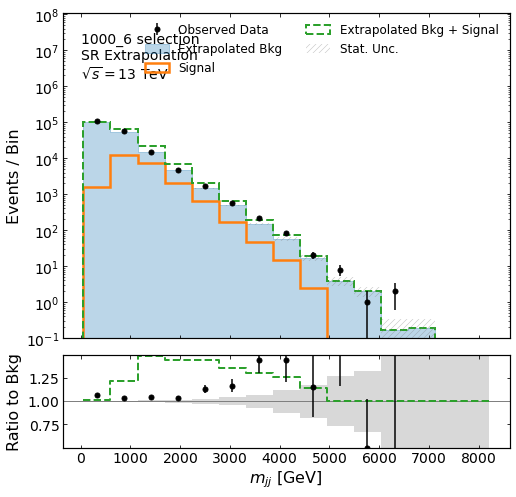

The optimal cut is 0.3368 yielding a significance of 73.23


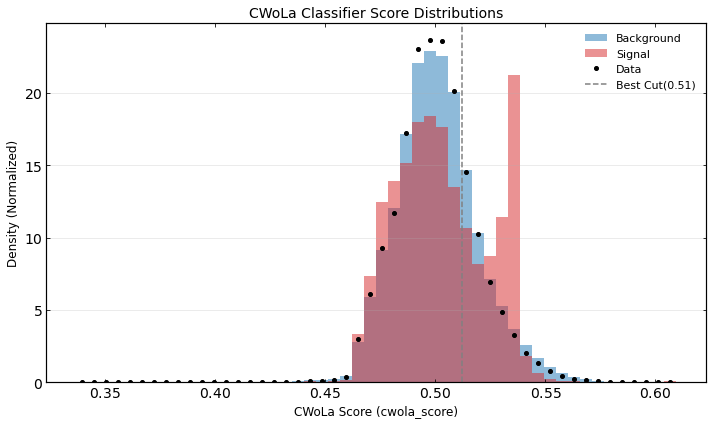


Processing Signal Mode: 1000_8...
Loading Signal: 1000_8...
  -> Loaded 17427 generated events.
  -> Total expected yield (Lumi = 25.3845 fb^-1): 42264.57 events.
Signal Columns: ['pT_j1', 'eta_j1', 'phi_j1', 'pT_j2', 'eta_j2', 'phi_j2', 'mjj', 'sm_jj', 'ljet1_tau21', 'ljet2_tau21', 'ljet1_tau32', 'ljet2_tau32', 'met_recalc_pt', 'phi_met', 'min_dPhi', 'ht', 'pt_balance', 'delta_phi_j1j2', 'final_weight']


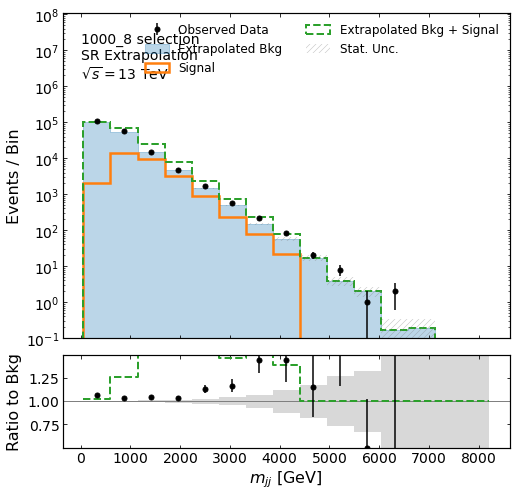

The optimal cut is 0.3392 yielding a significance of 98.12


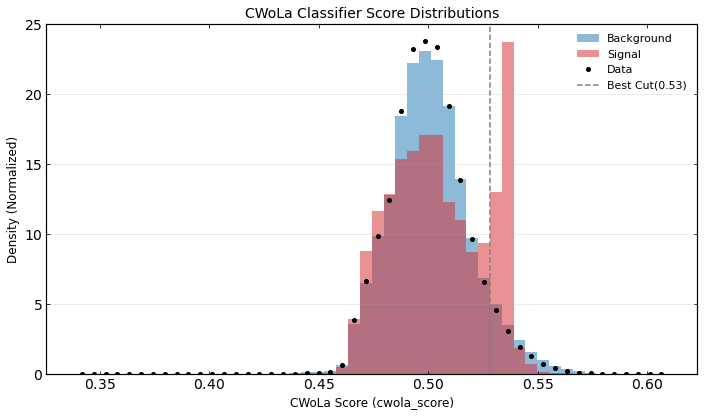


Processing Signal Mode: 2000_4...
Loading Signal: 2000_4...
  -> Loaded 20194 generated events.
  -> Total expected yield (Lumi = 25.3845 fb^-1): 752.52 events.
Signal Columns: ['pT_j1', 'eta_j1', 'phi_j1', 'pT_j2', 'eta_j2', 'phi_j2', 'mjj', 'sm_jj', 'ljet1_tau21', 'ljet2_tau21', 'ljet1_tau32', 'ljet2_tau32', 'met_recalc_pt', 'phi_met', 'min_dPhi', 'ht', 'pt_balance', 'delta_phi_j1j2', 'final_weight']


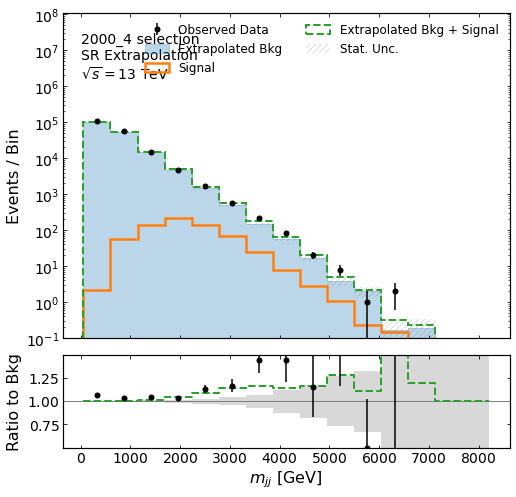

The optimal cut is 0.3384 yielding a significance of 1.69


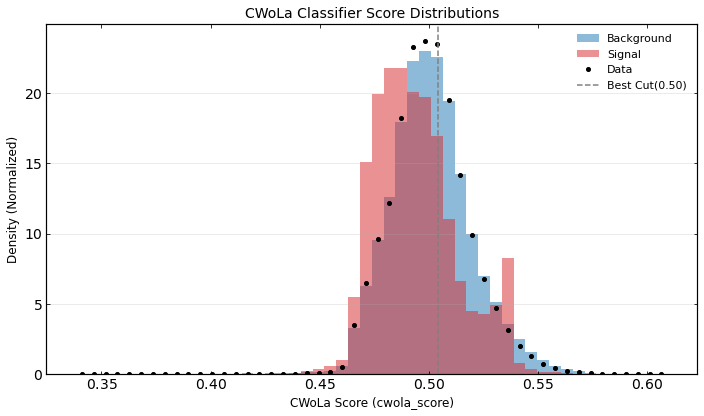


Processing Signal Mode: 2000_6...
Loading Signal: 2000_6...
  -> Loaded 30193 generated events.
  -> Total expected yield (Lumi = 25.3845 fb^-1): 1119.76 events.
Signal Columns: ['pT_j1', 'eta_j1', 'phi_j1', 'pT_j2', 'eta_j2', 'phi_j2', 'mjj', 'sm_jj', 'ljet1_tau21', 'ljet2_tau21', 'ljet1_tau32', 'ljet2_tau32', 'met_recalc_pt', 'phi_met', 'min_dPhi', 'ht', 'pt_balance', 'delta_phi_j1j2', 'final_weight']


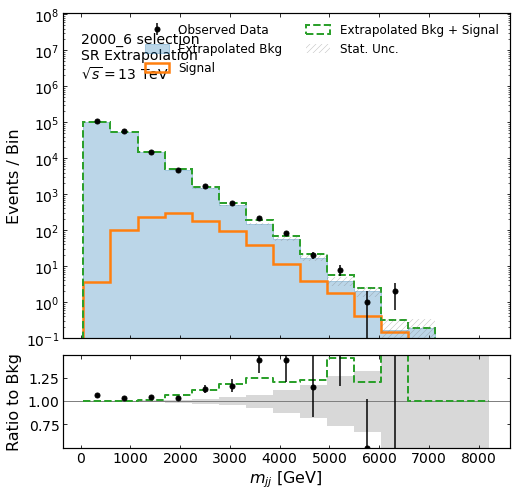

The optimal cut is 0.3385 yielding a significance of 2.53


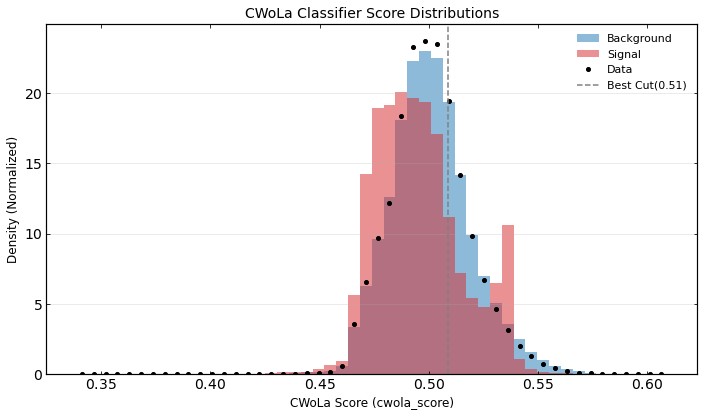


Processing Signal Mode: 3000_2...
Loading Signal: 3000_2...
  -> Loaded 5037 generated events.
  -> Total expected yield (Lumi = 25.3845 fb^-1): 18.21 events.
Signal Columns: ['pT_j1', 'eta_j1', 'phi_j1', 'pT_j2', 'eta_j2', 'phi_j2', 'mjj', 'sm_jj', 'ljet1_tau21', 'ljet2_tau21', 'ljet1_tau32', 'ljet2_tau32', 'met_recalc_pt', 'phi_met', 'min_dPhi', 'ht', 'pt_balance', 'delta_phi_j1j2', 'final_weight']


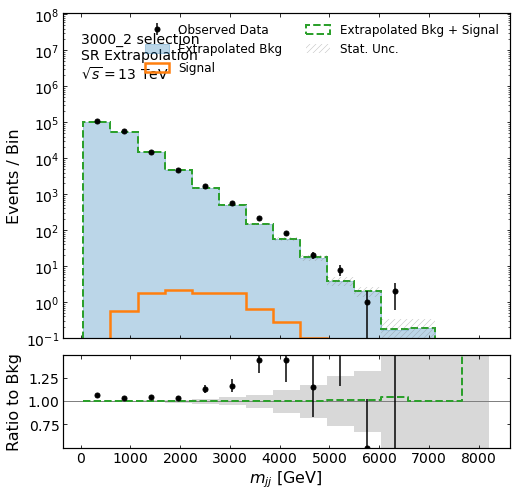

The optimal cut is 0.3970 yielding a significance of 0.03


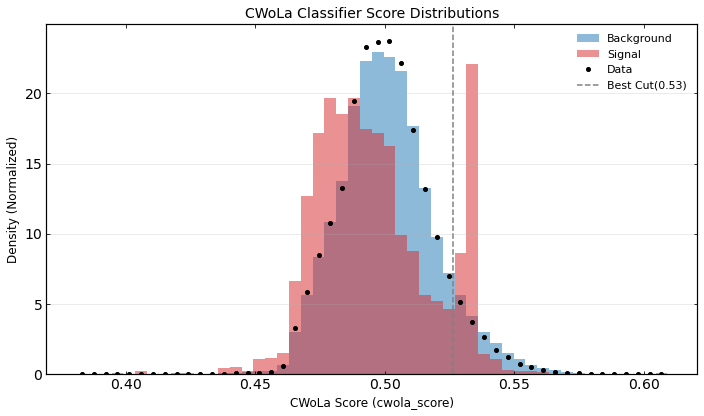


Processing Signal Mode: 3000_4...
Loading Signal: 3000_4...
  -> Loaded 10186 generated events.
  -> Total expected yield (Lumi = 25.3845 fb^-1): 36.72 events.
Signal Columns: ['pT_j1', 'eta_j1', 'phi_j1', 'pT_j2', 'eta_j2', 'phi_j2', 'mjj', 'sm_jj', 'ljet1_tau21', 'ljet2_tau21', 'ljet1_tau32', 'ljet2_tau32', 'met_recalc_pt', 'phi_met', 'min_dPhi', 'ht', 'pt_balance', 'delta_phi_j1j2', 'final_weight']


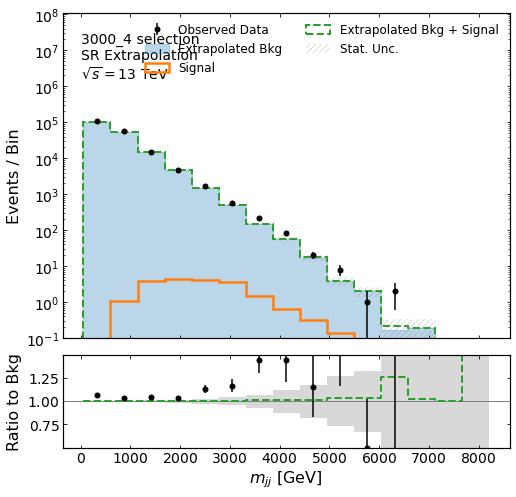

The optimal cut is 0.3499 yielding a significance of 0.05


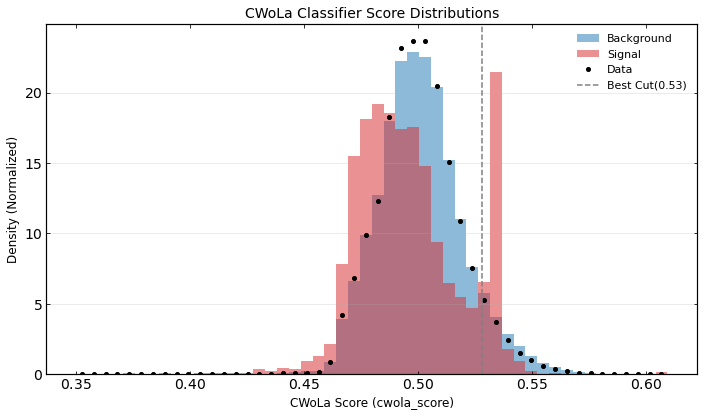

In [ ]:
# selection = "ML" # or ML
# bkg_type = "Nom" # Nom

for selection in ["ATLAS"]:
    for bkg_type in ["Extrap"]:

        if bkg_type == "Extrap":
            bkg_weight_col = "extrapolated_SR_weight"
        elif bkg_type == "Nom":
            bkg_weight_col = "final_weight"

        results = []

        print("Loading MC and Data in SR datasets...")

        df_mc = pl.read_parquet(f"AD_Events/SR_events_mc_{selection}.parquet")
        df_data = pl.read_parquet(f"AD_Events/SR_events_data_{selection}.parquet")

        print("MC and Data are loaded sucessfully")
        print(f"MC events: {len(df_mc)}, Data events: {len(df_data)}")
        print(f"MC columns: {df_mc.columns}")
        print(f"Data columns: {df_data.columns}")

        print("Unscaling MC and Data for plotting...")
        df_mc_unscaled = unscale_dataframe(df_mc, scaler, variables)
        df_data_unscaled = unscale_dataframe(df_data, scaler, variables)

        X_bkg_scaled = df_mc.select(features).to_numpy()
        X_data_scaled = df_data.select(features).to_numpy()

        # print(np.mean(X_bkg_scaled[:, 1])) 
        # print(np.mean(df_mc.select(features[1]).to_numpy()))

        eval_dir = f"Eval_CWoLa_SR_{selection}"
        code_prefix = f"Data_vs_{bkg_type}_{selection}"

        print("Running background inference...")
        final_bkg_scores = run_ensemble_inference(X_bkg_scaled, eval_dir, code_prefix)
        final_data_scores = run_ensemble_inference(X_data_scaled, eval_dir, code_prefix)

        # ATTACH SCORES
        df_mc_unscaled = df_mc_unscaled.with_columns(pl.Series(name="cwola_score", values=final_bkg_scores))
        df_data_unscaled = df_data_unscaled.with_columns(pl.Series(name="cwola_score", values=final_data_scores))

        for signal_mode in SIGNAL_MODES:
            print(f"\nProcessing Signal Mode: {signal_mode}...")
            mass, rinv = map(int, signal_mode.split('_'))
            if mass >= 3000:
                mu_max = 500.0
            elif mass >= 2000:
                mu_max = 50.0
            else:
                mu_max = 5.0

            df_signal = apply_sr_cuts(load_signal_for_cwola(signal_mode))
            # df_signal = apply_sr_cuts(load_signal_parquet_cwola(signal_mode))
            print(f"Signal Columns: {df_signal.columns}")

            plot_sr_signal_separated(
                mode_label=signal_mode,
                df_bkg=df_mc_unscaled,
                df_data=df_data_unscaled,
                df_signal=df_signal,
                feature="mjj",
                bkg_label="Extrapolated Bkg",
                bkg_weight_col=bkg_weight_col,
                signal_label="Signal",
                force_log=False
            )

            X_signal_scaled_full = scaler.transform(df_signal.select(variables).to_numpy())
            X_signal_scaled = X_signal_scaled_full[:, [variables.index(f) for f in features]]

            final_signal_scores = run_ensemble_inference(X_signal_scaled, eval_dir, code_prefix)
            df_signal = df_signal.with_columns(pl.Series(name="cwola_score", values=final_signal_scores))

            plot_cwola_scores(df_data_unscaled, df_mc_unscaled, df_signal, score_col="cwola_score", bins=50, density=True)
            # cut_threshold, max_significance, thresholds, significances = find_optimal_cwola_cut(df_signal, df_mc_unscaled, score_col="cwola_score")
            # cut_threshold = np.percentile(final_bkg_scores, 95)
            cut_threshold = find_best_cut(final_signal_scores)
            pass_bkg = df_mc_unscaled.filter(pl.col("cwola_score") > cut_threshold)
            pass_data = df_data_unscaled.filter(pl.col("cwola_score") > cut_threshold)
            pass_sig = df_signal.filter(pl.col("cwola_score") > cut_threshold)

            # HISTOGRAMS
            hist_bkg, _ = np.histogram(pass_bkg["mjj"].to_numpy(), bins=MJJ_BINS, weights=pass_bkg[bkg_weight_col].to_numpy())
            hist_data, _ = np.histogram(pass_data["mjj"].to_numpy(), bins=MJJ_BINS)
            hist_sig, _ = np.histogram(pass_sig["mjj"].to_numpy(), bins=MJJ_BINS, weights=pass_sig["final_weight"].to_numpy())
            hist_bkg_var, _ = np.histogram(pass_bkg["mjj"].to_numpy(), bins=MJJ_BINS, weights=pass_bkg[bkg_weight_col].to_numpy() ** 2)

            # SAFE HISTOGRAMS
            epsilon = 1e-6
            hist_bkg_safe = np.where(hist_bkg <= 0, epsilon, hist_bkg)
            hist_bkg_var_safe = np.where(hist_bkg_var <= 0, epsilon, hist_bkg_var)

            # PYHF MODEL
            model_spec = {
                "channels": [{"name": "SR_mjj", "samples": [
                    {"name": "Background", "data": hist_bkg_safe.tolist(), "modifiers": [{"name": "stat_uncert", "type": "staterror", "data": np.sqrt(hist_bkg_var_safe).tolist()}]},
                    {"name": "Signal", "data": hist_sig.tolist(), "modifiers": [{"name": "mu", "type": "normfactor", "data": None}]}
                ]}],
                "observations": [{"name": "SR_mjj", "data": hist_data.tolist()}],
                "measurements": [{"name": "Limit", "config": {"poi": "mu", "parameters": [{"name": "mu", "bounds": [[0.0, mu_max]]}]}}],
                "version": "1.0.0"
            }

            workspace = pyhf.Workspace(model_spec)
            model = workspace.model()
            data_ws = workspace.data(model)

            # LIMIT SCAN
            mu_scan = np.linspace(0.01, mu_max, 150)
            obs_cls_list, exp_cls_list = [], []

            for mu in mu_scan:
                obs, exp = pyhf.infer.hypotest(float(mu), data_ws, model, test_stat="qtilde", return_expected_set=True)
                obs_cls_list.append(obs)
                exp_cls_list.append(exp)

            obs_cls = np.array(obs_cls_list)
            exp_cls_set = np.array(exp_cls_list).T

            obs_limit = find_limit(mu_scan, obs_cls)
            exp_m2 = find_limit(mu_scan, exp_cls_set[0])
            exp_m1 = find_limit(mu_scan, exp_cls_set[1])
            exp_med = find_limit(mu_scan, exp_cls_set[2])
            exp_p1 = find_limit(mu_scan, exp_cls_set[3])
            exp_p2 = find_limit(mu_scan, exp_cls_set[4])

            # STORE RESULTS
            xs, _ = get_metadata(signal_mode)
            # print(xs)
            # print(exp_med)
            results.append({
                "selection": selection, "mass": mass, "rinv": rinv,
                "obs_limit": obs_limit, "exp_limit": exp_med,
                "exp_p1": exp_p1, "exp_m1": exp_m1, "exp_p2": exp_p2, "exp_m2": exp_m2,
                "xs": xs, "obs_xs_limit": obs_limit * xs, "exp_xs_limit": exp_med * xs,
            })
            print(f"Expected μ limit: {exp_med:.3f}")

        results_df = pd.DataFrame(results)
        results_df.to_csv(f"cwola_2d_limit_scan_{selection}_{bkg_type}.csv", index=False)
        print(f"Saved results to cwola_2d_limit_scan_{selection}_{bkg_type}.csv")

In [6]:
.

SyntaxError: invalid syntax (1933637684.py, line 1)

/home/aegis/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


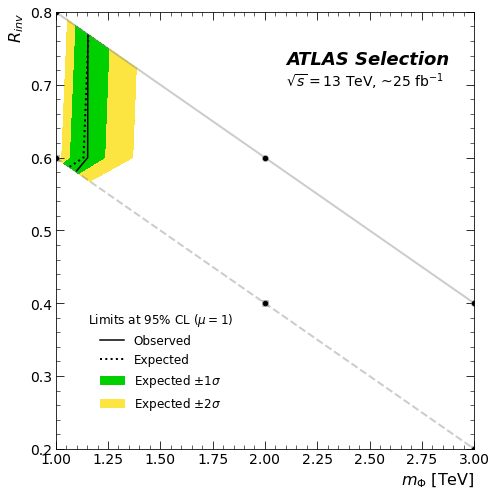

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

selection = "ATLAS"
bkg_type = "Extrap"

# 1. Load your DataFrame
results_df = pd.read_csv(f"cwola_2d_limit_scan_{selection}_{bkg_type}_95.csv")

# 2. Extract unique grid coordinates
masses = sorted(results_df["mass"].unique())
rinvs = sorted(results_df["rinv"].unique())

# Create a sparse 2D grid based ONLY on your simulated points
X, Y = np.meshgrid(masses, rinvs)

# Initialize Z grids with NaNs
Z_obs = np.full(X.shape, np.nan)
Z_exp = np.full(X.shape, np.nan)
Z_m2  = np.full(X.shape, np.nan)
Z_m1  = np.full(X.shape, np.nan)
Z_p1  = np.full(X.shape, np.nan)
Z_p2  = np.full(X.shape, np.nan)

# Fill the grids with your actual data
for i, rinv in enumerate(rinvs):
    for j, mass in enumerate(masses):
        row = results_df[(results_df["mass"] == mass) & (results_df["rinv"] == rinv)]
        if not row.empty:
            Z_obs[i, j] = row["obs_limit"].values[0]
            Z_exp[i, j] = row["exp_limit"].values[0]
            Z_m2[i, j]  = row["exp_m2"].values[0]
            Z_m1[i, j]  = row["exp_m1"].values[0]
            Z_p1[i, j]  = row["exp_p1"].values[0]
            Z_p2[i, j]  = row["exp_p2"].values[0]

# Convert for plotting axes (TeV and 0.X)
X_plot = X / 1000.0
Y_plot = Y / 10.0

# 3. Setup the Plot
fig, ax = plt.subplots(figsize=(7, 7))

# =====================================================================
# THE RAW LAYERING TRICK
# Because we are using the sparse X_plot/Y_plot grids, Matplotlib will 
# natively draw straight, jagged lines between the crossing points.
# =====================================================================

ax.contourf(X_plot, Y_plot, Z_m2, levels=[0, 1.0], colors=['#FDE541'])
ax.contourf(X_plot, Y_plot, Z_m1, levels=[0, 1.0], colors=['#00D000'])
ax.contourf(X_plot, Y_plot, Z_p1, levels=[0, 1.0], colors=['#FDE541'])
ax.contourf(X_plot, Y_plot, Z_p2, levels=[0, 1.0], colors=['white'])

# Draw the Hard Lines
ax.contour(X_plot, Y_plot, Z_exp, levels=[1.0], colors='black', linestyles=':', linewidths=2)
ax.contour(X_plot, Y_plot, Z_obs, levels=[1.0], colors='black', linestyles='-', linewidths=1.5)

# =====================================================================
# DRAW THE "DOTS"
# Plot the exact points you simulated so you can see the skeleton
# =====================================================================
simulated_masses = results_df['mass'].values / 1000.0
simulated_rinvs = results_df['rinv'].values / 10.0

ax.scatter(simulated_masses, simulated_rinvs, color='black', s=20, zorder=5)


# 4. Styling and Formatting
ax.set_xlabel(r'$m_\Phi$ [TeV]', fontsize=16, loc='right')
ax.set_ylabel(r'$R_{inv}$', fontsize=16, loc='top')

ax.tick_params(axis='both', which='major', labelsize=14, direction='in', length=8, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=4, top=True, right=True)
ax.minorticks_on()

# ===========
# Plot Lines
# ===========

# Line 1 Data (m, rinv)
m_line1 = [1.0, 2.0, 3.0]
rinv_line1 = [0.8, 0.6, 0.4]

# Line 2 Data (m, rinv)
m_line2 = [1.0, 2.0, 3.0]
rinv_line2 = [0.6, 0.4, 0.2]

# Draw Line 1 (Solid blue line with circular markers)
ax.plot(m_line1, rinv_line1, marker='o', linestyle='-', color='grey', linewidth=2, alpha=0.4)

# Draw Line 2 (Dashed red line with square markers)
ax.plot(m_line2, rinv_line2, marker='s', linestyle='--', color='grey', linewidth=2, alpha=0.4)



ax.text(0.55, 0.88, 'ATLAS Selection', transform=ax.transAxes, fontsize=18, fontweight='bold', style='italic')
ax.text(0.55, 0.83, r'$\sqrt{s} = 13$ TeV, ~25 fb$^{-1}$', transform=ax.transAxes, fontsize=14)
# ax.text(0.55, 0.75, 'Raw Connected Limit', transform=ax.transAxes, fontsize=12)




legend_elements = [
    Line2D([0], [0], color='black', lw=1.5, linestyle='-', label='Observed'),
    Line2D([0], [0], color='black', lw=2, linestyle=':', label='Expected'),
    mpatches.Patch(color='#00D000', label=r'Expected $\pm 1\sigma$'),
    mpatches.Patch(color='#FDE541', label=r'Expected $\pm 2\sigma$'),
    # Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markersize=6, label='Simulated Points')
]

ax.legend(handles=legend_elements, loc='center right', bbox_to_anchor=(0.45, 0.2), 
          frameon=False, fontsize=12, title="Limits at 95% CL ($\mu=1$)", title_fontsize=12)
ax.set_xlim(1, 3)
plt.tight_layout()
plt.show()

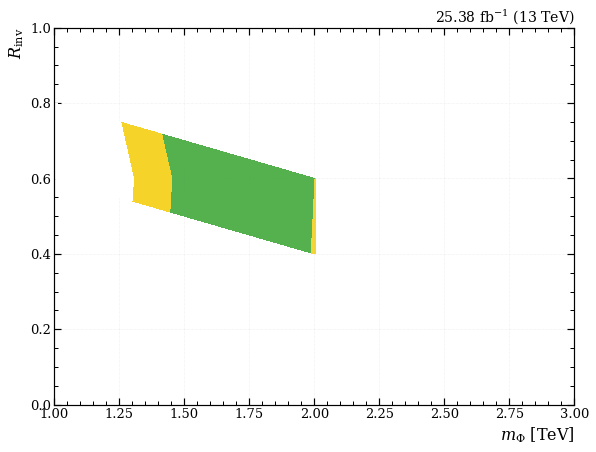

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# =========================================================
# Configuration
# =========================================================
selection = "ATLAS"
bkg_type = "Extrap"

# =========================================================
# Load data
# =========================================================
results_df = pd.read_csv(
    f"cwola_2d_limit_scan_{selection}_{bkg_type}.csv"
)

# =========================================================
# Extract grid coordinates
# =========================================================
masses = sorted(results_df["mass"].unique())
rinvs  = sorted(results_df["rinv"].unique())

X, Y = np.meshgrid(masses, rinvs)

# =========================================================
# Initialize sparse grids
# =========================================================
Z_obs = np.full(X.shape, np.nan)
Z_exp = np.full(X.shape, np.nan)

Z_m2 = np.full(X.shape, np.nan)
Z_m1 = np.full(X.shape, np.nan)
Z_p1 = np.full(X.shape, np.nan)
Z_p2 = np.full(X.shape, np.nan)

# =========================================================
# Fill sparse grids
# =========================================================
for i, rinv in enumerate(rinvs):
    for j, mass in enumerate(masses):

        row = results_df[
            (results_df["mass"] == mass) &
            (results_df["rinv"] == rinv)
        ]

        if not row.empty:

            Z_obs[i, j] = row["obs_limit"].values[0]
            Z_exp[i, j] = row["exp_limit"].values[0]

            Z_m2[i, j] = row["exp_m2"].values[0]
            Z_m1[i, j] = row["exp_m1"].values[0]

            Z_p1[i, j] = row["exp_p1"].values[0]
            Z_p2[i, j] = row["exp_p2"].values[0]

# =========================================================
# Axis units
# =========================================================
X_plot = X / 1000.0
Y_plot = Y / 10.0

# =========================================================
# Global plotting style
# =========================================================
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "dejavuserif",
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.linewidth": 1.2,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
})

# =========================================================
# Figure
# =========================================================
fig, ax = plt.subplots(figsize=(8.5, 6.5))

# =========================================================
# Expected bands
# =========================================================

# 2 sigma (yellow)
ax.contourf(
    X_plot,
    Y_plot,
    Z_m2,
    levels=[0, 1.0],
    colors=['#F5D328'],
    alpha=0.95,
    zorder=1
)

# 1 sigma (green)
ax.contourf(
    X_plot,
    Y_plot,
    Z_m1,
    levels=[0, 1.0],
    colors=['#4CAF50'],
    alpha=0.95,
    zorder=2
)

# remove inner overlap
ax.contourf(
    X_plot,
    Y_plot,
    Z_p1,
    levels=[0, 1.0],
    colors=['#F5D328'],
    zorder=3
)

ax.contourf(
    X_plot,
    Y_plot,
    Z_p2,
    levels=[0, 1.0],
    colors=['white'],
    zorder=4
)

# # =========================================================
# # Contours
# # =========================================================

# # # Expected
# exp_contour = ax.contour(
#     X_plot,
#     Y_plot,
#     Z_exp,
#     levels=[1.0],
#     colors='black',
#     linestyles='--',
#     linewidths=2.2,
#     zorder=5
# )

# # Observed
# obs_contour = ax.contour(
#     X_plot,
#     Y_plot,
#     Z_obs,
#     levels=[1.0],
#     colors='black',
#     linestyles='-',
#     linewidths=2.5,
#     zorder=6
# )

# =========================================================
# Simulated points
# =========================================================
simulated_masses = results_df['mass'].values / 1000.0
simulated_rinvs  = results_df['rinv'].values / 10.0

# ax.scatter(
#     simulated_masses,
#     simulated_rinvs,
#     color='black',
#     s=35,
#     alpha=0.8,
#     zorder=7
# )

# =========================================================
# Guide lines
# =========================================================
m_line1 = [1.0, 2.0, 3.0]
rinv_line1 = [0.8, 0.6, 0.4]

m_line2 = [1.0, 2.0, 3.0]
rinv_line2 = [0.6, 0.4, 0.2]

# ax.plot(
#     m_line1,
#     rinv_line1,
#     linestyle='--',
#     linewidth=2,
#     color='gray',
#     alpha=0.25
# )

# ax.plot(
#     m_line2,
#     rinv_line2,
#     linestyle='--',
#     linewidth=2,
#     color='gray',
#     alpha=0.25
# )

# =========================================================
# Labels
# =========================================================
ax.set_xlabel(r'$m_{\Phi}$ [TeV]', loc='right')
ax.set_ylabel(r'$R_{\mathrm{inv}}$', loc='top')

# =========================================================
# Ticks
# =========================================================
ax.tick_params(
    axis='both',
    which='major',
    direction='in',
    top=True,
    right=True,
    length=7,
    width=1.2
)

ax.tick_params(
    axis='both',
    which='minor',
    direction='in',
    top=True,
    right=True,
    length=4,
    width=1.0
)

ax.minorticks_on()

# =========================================================
# Grid
# =========================================================
ax.grid(
    which='major',
    linestyle=':',
    linewidth=0.5,
    alpha=0.4
)

# =========================================================
# Limits
# =========================================================
ax.set_xlim(1.0, 3.0)
ax.set_ylim(0.0, 1.0)

# =========================================================
# ATLAS-style annotations
# =========================================================

# ax.text(
#     0.03,
#     0.90,
#     r'$\sqrt{s}=13$ TeV, 25.38 fb$^{-1}$',
#     transform=ax.transAxes,
#     fontsize=14,
#     va='top'
# )


# =========================================================
# Legend
# =========================================================
# legend_elements = [

#     Line2D(
#         [0], [0],
#         color='black',
#         lw=2.5,
#         linestyle='-',
#         label='Observed'
#     ),

#     Line2D(
#         [0], [0],
#         color='black',
#         lw=2.2,
#         linestyle='--',
#         label='Expected'
#     ),

#     mpatches.Patch(
#         color='#4CAF50',
#         label=r'Expected $\pm 1\sigma$'
#     ),

#     mpatches.Patch(
#         color='#F5D328',
#         label=r'Expected $\pm 2\sigma$'
#     ),

#     Line2D(
#         [0], [0],
#         marker='o',
#         color='w',
#         markerfacecolor='black',
#         markersize=6,
#         label='Simulated points'
#     )
# ]
ax.set_title(r'25.38 fb$^{-1}$ (13 TeV)', fontsize=14, loc="right")

# ax.legend(
#     handles=legend_elements,
#     loc='lower left',
#     frameon=True,
#     # title=r'95% CL Exclusion',
#     title_fontsize=12
# )
# Force spines (the frame) to be on top of the white contour
for spine in ax.spines.values():
    spine.set_zorder(10)

# Force ticks to be on top
ax.tick_params(zorder=10)
# =========================================================
# Layout + export
# =========================================================
plt.tight_layout()

plt.savefig(
    "cwola_2d_exclusion.pdf",
    bbox_inches='tight'
)

plt.savefig(
    "Exclusion_Plot.pdf",
    dpi=400,
    bbox_inches='tight'
)

plt.show()

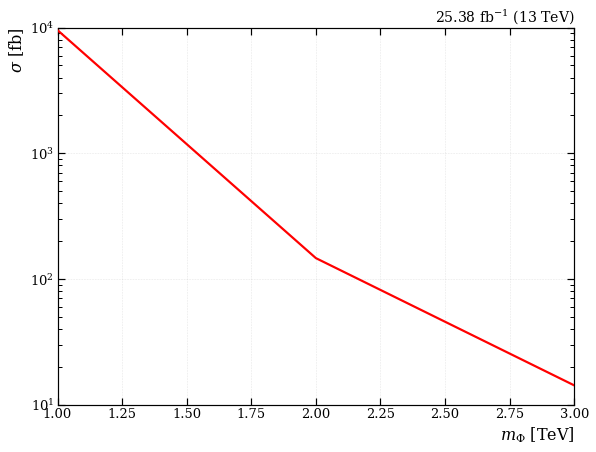

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, NullFormatter

# =========================================================
# Load data
# =========================================================
df = pd.read_csv("cwola_2d_limit_scan_ATLAS_Extrap.csv")

# =========================================================
# Compute cross-section scaled bands
# =========================================================
df['exp_p1_xs'] = df['exp_p1'] * df['xs']
df['exp_m1_xs'] = df['exp_m1'] * df['xs']
df['exp_p2_xs'] = df['exp_p2'] * df['xs']
df['exp_m2_xs'] = df['exp_m2'] * df['xs']

# Average over rinv
df_avg = df.groupby('mass').mean(numeric_only=True).reset_index()

# Convert to TeV
masses = df_avg['mass'] / 1000.0

# =========================================================
# Global plotting style
# =========================================================
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 15,
    "legend.fontsize": 13,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "font.family": "serif",
    "mathtext.fontset": "dejavuserif",
    "axes.linewidth": 1.2,
})

# =========================================================
# Create figure
# =========================================================
fig, ax = plt.subplots(figsize=(8.5, 6.5))

# =========================================================
# Expected uncertainty bands
# =========================================================
# band2 = ax.fill_between(
#     masses,
#     df_avg['exp_m2_xs'],
#     df_avg['exp_p2_xs'],
#     color='#F5D328',
#     alpha=0.9,
#     label=r'Expected $\pm 2\sigma$',
#     zorder=1
# )

# band1 = ax.fill_between(
#     masses,
#     df_avg['exp_m1_xs'],
#     df_avg['exp_p1_xs'],
#     color='#4CAF50',
#     alpha=0.95,
#     label=r'Expected $\pm 1\sigma$',
#     zorder=2
# )

# =========================================================
# Expected limit
# =========================================================
# exp_line, = ax.plot(
#     masses,
#     df_avg['exp_xs_limit'],
#     linestyle='--',
#     color='black',
#     linewidth=2.2,
#     label='Expected',
#     zorder=3
# )

# =========================================================
# Observed limit
# =========================================================
# obs_line, = ax.plot(
#     masses,
#     df_avg['obs_xs_limit'],
#     linestyle='-',
#     color='black',
#     linewidth=2.4,
#     marker='o',
#     markersize=5,
#     label='Observed',
#     zorder=4
# )

# =========================================================
# Theory prediction
# =========================================================
theory_line, = ax.plot(
    masses,
    df_avg['xs'],
    color='red',
    linewidth=2.2,
    linestyle='-',
    label='Theory prediction',
    zorder=3
)

# =========================================================
# Axes formatting
# =========================================================
ax.set_yscale('log')

ax.set_xlabel(r'$m_{\Phi}$ [TeV]', loc = "right")
ax.set_ylabel(r'$\sigma$ [fb]', loc = "top")

# Tick styling
ax.tick_params(
    axis='both',
    which='major',
    direction='in',
    top=True,
    right=True,
    length=7,
    width=1.2
)

ax.tick_params(
    axis='both',
    which='minor',
    direction='in',
    top=True,
    right=True,
    length=4,
    width=1.0
)

# Log-scale minor ticks
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs='auto'))
ax.yaxis.set_minor_formatter(NullFormatter())

# =========================================================
# Grid
# =========================================================
ax.grid(
    which='major',
    linestyle=':',
    linewidth=0.6,
    alpha=0.5
)

# =========================================================
# Limits
# =========================================================
ax.set_title(r'25.38 fb$^{-1}$ (13 TeV)', fontsize=14, loc="right")
ax.set_xlim(1, 3)
ax.set_ylim(10, 10000)
# =========================================================
# Legend
# =========================================================
# handles = [
#     obs_line,
#     exp_line,
#     band1,
#     band2,
#     theory_line
# ]

labels = [
    'Observed',
    'Expected',
    r'Expected $\pm 1\sigma$',
    r'Expected $\pm 2\sigma$',
    'Theory prediction'
]

# ax.legend(
#     handles,
#     labels,
#     loc='lower left',
#     frameon=True
# )

# =========================================================
# Layout
# =========================================================
plt.tight_layout()
plt.savefig("cross_section_limit.pdf", bbox_inches='tight')
# plt.savefig("limit_plot.png", dpi=400, bbox_inches='tight')

plt.show()

In [ ]:
.. asd

SyntaxError: invalid syntax (213488585.py, line 1)

In [ ]:
from scipy.stats import skew

def prong_stats(arr, weights=None, name="sample"):
    arr = np.asarray(arr)
    
    if len(arr) == 0:
        print(f"{name}: empty")
        return
    
    # Weighted mean/std if weights provided
    if weights is not None:
        w = np.asarray(weights)
        mean = np.average(arr, weights=w)
        var = np.average((arr - mean)**2, weights=w)
        std = np.sqrt(var)
    else:
        mean = np.mean(arr)
        std = np.std(arr)
    
    med = np.median(arr)
    sk = skew(arr)  # unweighted skewness (good enough for shape comparison)

    # “signal-like” fractions (physics-motivated heuristics)
    frac_low_05 = np.mean(arr < 0.5)
    frac_low_04 = np.mean(arr < 0.4)

    print(f"\n--- {name} ---")
    print(f"Mean:   {mean:.3f}")
    print(f"Median: {med:.3f}")
    print(f"Std:    {std:.3f}")
    print(f"Skew:   {sk:.3f} ( >0 = right-skew )")
    print(f"Frac < 0.5: {frac_low_05:.3f}")
    print(f"Frac < 0.4: {frac_low_04:.3f}")

def prong_stats_rigorous(arr, weights=None, name="sample"):
    arr = np.asarray(arr)
    
    # 1. Physical Bounds Masking
    # N-subjettiness is strictly [0, 1]. This removes -99, -999, NaNs, and Infs.
    valid_mask = np.isfinite(arr) & (arr >= 0) & (arr <= 1)
    clean_arr = arr[valid_mask]
    
    if len(clean_arr) == 0:
        print(f"{name}: Empty or entirely invalid data.")
        return
        
    if weights is not None:
        w = np.asarray(weights)[valid_mask]
    else:
        w = np.ones_like(clean_arr)
        
    if np.sum(w) == 0:
        print(f"{name}: Zero total weight after cleaning.")
        return

    # Normalize weights to avoid precision loss on large cross-sections
    w_norm = w / np.sum(w)

    # 2. Fully Weighted Mean, Variance, and Std
    mean = np.average(clean_arr, weights=w_norm)
    var = np.average((clean_arr - mean)**2, weights=w_norm)
    std = np.sqrt(var)

    # 3. Fully Weighted Skewness
    # E[(x-mean)^3] / std^3
    m3 = np.average((clean_arr - mean)**3, weights=w_norm)
    skew = m3 / (std**3) if std > 0 else 0

    # 4. Fully Weighted Median
    # Sort the array and weights to find where the cumulative weight hits 50%
    sort_idx = np.argsort(clean_arr)
    sorted_arr = clean_arr[sort_idx]
    sorted_w = w_norm[sort_idx]
    cum_w = np.cumsum(sorted_w)
    median_idx = np.searchsorted(cum_w, 0.5)
    median = sorted_arr[median_idx]

    # 5. Fully Weighted Fractions
    frac_low_05 = np.average(clean_arr < 0.5, weights=w_norm)
    frac_low_04 = np.average(clean_arr < 0.4, weights=w_norm)

    print(f"\n--- {name} ---")
    print(f"Valid Jets: {len(clean_arr)} (Filtered out {len(arr) - len(clean_arr)} unphysical values)")
    print(f"Mean:   {mean:.3f}")
    print(f"Median: {median:.3f}")
    print(f"Std:    {std:.3f}")
    print(f"Skew:   {skew:.3f} ( >0 = right-skew )")
    print(f"Frac < 0.5: {frac_low_05:.3f}")
    print(f"Frac < 0.4: {frac_low_04:.3f}")

In [ ]:
def plot_sr_signals_overlay(
    mode_label: str, 
    df_bkg: pl.DataFrame, 
    df_data: pl.DataFrame, 
    dict_signals: dict, 
    feature: str, 
    bkg_label: str = "Extrapolated Bkg",
    bkg_weight_col: str = "extrapolated_SR_weight",
    force_log: bool = False
):
    """
    Plots Data and Background with multiple Signal overlays (unstacked).
    dict_signals should be formatted as {"Signal Label": pl.DataFrame}
    """
    plt.rcParams.update({
        'font.size': 14, 'axes.labelsize': 16, 'xtick.labelsize': 14, 'ytick.labelsize': 14,
        'legend.fontsize': 12, 'lines.linewidth': 1.5, 'xtick.direction': 'in', 'ytick.direction': 'in',
        'xtick.top': True, 'ytick.right': True, 'axes.formatter.use_mathtext': True, 'axes.linewidth': 1.2,
        'hatch.linewidth': 0.5
    })
    
    pretty_labels = {
        'ht': r'$H_{T}$ [GeV]', 'met_recalc_pt': r'$E_{T}^{\text{miss}}$ [GeV]', 'met': r'$E_{T}^{\text{miss}}$ [GeV]', 
        'mjj': r'$m_{jj}$ [GeV]', 'ljet1_tau21': r'Leading jet $\tau_{21}$', 'ljet1_tau32': r'Leading jet $\tau_{32}$',
        'ljet2_tau21': r'Subleading jet $\tau_{21}$', 'ljet2_tau32': r'Subleading jet $\tau_{32}$'
    }
    
    use_log = force_log or any(log_var in feature.lower() for log_var in ['ht', 'met_recalc_pt', 'met', 'mjj'])
    
    # Extract Arrays
    data_arr = df_data.get_column(feature).drop_nulls().to_numpy()
    bkg_arr = df_bkg.get_column(feature).drop_nulls().to_numpy()
    
    if len(data_arr) == 0:
        print(f"Skipping {feature} - No valid observed data.")
        return
        
    # Extract Background Weights
    bkg_weights = df_bkg.get_column(bkg_weight_col).to_numpy()
    
    # Setup Figure
    fig = plt.figure(figsize=(8, 8))
    gs = gridspec.GridSpec(2, 1, height_ratios=[3.5, 1], hspace=0.08)
    ax_main = fig.add_subplot(gs[0])
    ax_ratio = fig.add_subplot(gs[1], sharex=ax_main)
    
    # Binning (based on Data and Background)
    combined_arr = np.concatenate([data_arr, bkg_arr])
    bins = np.histogram_bin_edges(combined_arr, bins=15)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    bin_widths = np.diff(bins)

    # --- 1. BACKGROUND (Filled) ---
    counts_bkg, _ = np.histogram(bkg_arr, bins=bins, weights=bkg_weights)
    sumw2_bkg, _ = np.histogram(bkg_arr, bins=bins, weights=bkg_weights**2)
    bkg_err = np.sqrt(sumw2_bkg)
    
    ax_main.hist(bkg_arr, bins=bins, weights=bkg_weights, histtype='stepfilled', 
                 color='#1f78b4', alpha=0.3, edgecolor='#1f78b4', label=bkg_label)
    
    ax_main.bar(bin_centers, 2 * bkg_err, bottom=counts_bkg - bkg_err, width=bin_widths, 
                color='none', edgecolor='gray', hatch='////', linewidth=0, alpha=0.5, zorder=5, label='Stat. Unc.')

    # --- 2. SIGNALS (Overlay) ---
    # Define a distinct color palette for multiple signals
    sig_colors = ['#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#bcbd22', '#17becf']
    
    for idx, (sig_label, df_sig) in enumerate(dict_signals.items()):
        if df_sig is not None:
            sig_arr = df_sig.get_column(feature).drop_nulls().to_numpy()
            sig_weights = df_sig.get_column("final_weight").to_numpy()
            
            if len(sig_arr) > 0:
                color = sig_colors[idx % len(sig_colors)]
                ax_main.hist(sig_arr, bins=bins, weights=sig_weights, histtype='step', 
                             color=color, linewidth=2.0, label=sig_label)

    # --- 3. OBSERVED DATA ---
    counts_data, _ = np.histogram(data_arr, bins=bins)
    data_errors = np.sqrt(counts_data)
    ax_main.errorbar(bin_centers, counts_data, yerr=data_errors, fmt='ko', 
                     label='Observed Data', zorder=10, capsize=0, markersize=5)
    
    # --- STYLING MAIN PANEL ---
    y_max = max(np.max(counts_data) + np.max(data_errors), np.max(counts_bkg + bkg_err))
    if use_log:
        ax_main.set_yscale('log')
        ax_main.set_ylim(0.1, y_max * 1000) 
    else:
        ax_main.set_ylim(0, y_max * 1.55) 
        ax_main.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        
    ax_main.set_ylabel("Events / Bin")
    plt.setp(ax_main.get_xticklabels(), visible=False)
    
    # ax_main.text(0.04, 0.94, f"{mode_label} selection\nSR Extrapolation\n" + r"$\sqrt{s} = 13$ TeV", 
    #              transform=ax_main.transAxes, fontsize=14, verticalalignment='top')
                 
    # Reorder legend to ensure Data is always first and Bkg is second
    handles, loc_labels = ax_main.get_legend_handles_labels()
    
    # Sort legend items logically
    ordered_handles, ordered_labels = [], []
    for target in ["Observed Data", bkg_label, "Stat. Unc."]:
        if target in loc_labels:
            idx = loc_labels.index(target)
            ordered_handles.append(handles.pop(idx))
            ordered_labels.append(loc_labels.pop(idx))
            
    # Append the rest (signals)
    ordered_handles.extend(handles)
    ordered_labels.extend(loc_labels)
    
    ax_main.legend(ordered_handles, ordered_labels, loc='upper right', frameon=False, ncol=2)
    
    # --- RATIO PANEL ---
    with np.errstate(divide='ignore', invalid='ignore'):
        # Data / Background
        ratio_data = np.where(counts_bkg > 0, counts_data / counts_bkg, np.nan)
        rel_err_data = np.where(counts_data > 0, data_errors / counts_data, 0)
        rel_err_bkg = np.where(counts_bkg > 0, bkg_err / counts_bkg, 0)
        ratio_data_err = np.abs(ratio_data) * np.sqrt(rel_err_data**2 + rel_err_bkg**2)

    # Uncertainty band around 1.0 (Background Stat Unc)
    ax_ratio.bar(bin_centers, 2 * rel_err_bkg, bottom=1.0 - rel_err_bkg, width=bin_widths, 
                 color='gray', hatch='////', edgecolor='none', alpha=0.3, zorder=1)
    ax_ratio.axhline(1.0, color='gray', linestyle='-', linewidth=1.0, zorder=2)
    
    # Plot Data points
    ax_ratio.errorbar(bin_centers, ratio_data, yerr=ratio_data_err, fmt='ko', capsize=0, markersize=5, zorder=10)
    
    ax_ratio.set_xlabel(pretty_labels.get(feature, feature))
    ax_ratio.set_ylabel("Data / Bkg")
    ax_ratio.set_ylim(0.5, 1.5)
    ax_ratio.set_yticks([0.75, 1.0, 1.25])
    
    fig.align_ylabels((ax_main, ax_ratio))
    
    os.makedirs("Bkg_Sig_plots", exist_ok=True)
    plt.savefig(f"Bkg_Sig_plots/SR_{mode_label}_{feature}_overlay.pdf", bbox_inches='tight')
    plt.show()
    plt.close(fig)

In [ ]:
selection = "ATLAS"
df_mc = pl.read_parquet(f"AD_Events/SR_events_mc_{selection}.parquet")
df_data = pl.read_parquet(f"AD_Events/SR_events_data_{selection}.parquet")

print("MC and Data are loaded sucessfully")
print(f"MC events: {len(df_mc)}, Data events: {len(df_data)}")
print(f"MC columns: {df_mc.columns}")
print(f"Data columns: {df_data.columns}")

print("Unscaling MC and Data for plotting...")
df_mc_unscaled = unscale_dataframe(df_mc, scaler, variables)
df_data_unscaled = unscale_dataframe(df_data, scaler, variables)

my_signals = {}
for mode in SIGNAL_MODES:
    # Extract mass and Rinv for a clean legend label
    mass, rinv = mode.split('_')
    
    # Load and apply cuts
    df_sig = apply_sr_cuts(load_signal_for_cwola(mode))
    
    # Format the label nicely (e.g., "Signal (m=1000, Rinv=6)")
    label = rf"Signal ($m={mass}, R_{{inv}}={rinv}$)"
    my_signals[label] = df_sig

# 3. Generate the overlay plot for your chosen feature (e.g., 'mjj')
for var in variables:
    # print(f"\nGenerating overlay plot for {var}...")
    
    # plot_sr_signals_overlay(
    #     mode_label="ATLAS",
    #     df_bkg=df_mc_unscaled,
    #     df_data=df_data_unscaled,
    #     dict_signals=my_signals,
    #     feature=var, 
    #     bkg_label="Extrapolated Bkg",
    #     bkg_weight_col="extrapolated_SR_weight", # Change to "final_weight" if testing bkg_type="Nom"
    #     force_log=False
    # )

    if var in ["ljet1_tau21", "ljet1_tau32", "ljet2_tau21", "ljet2_tau32"]:
        print("Analyzing pronginess statistics for variable:", var)
        prong_stats_rigorous(df_data_unscaled.get_column(var).drop_nulls().to_numpy(), name="Data")
        prong_stats_rigorous(df_mc_unscaled.get_column(var).drop_nulls().to_numpy(), weights=df_mc_unscaled.get_column("extrapolated_SR_weight").to_numpy(), name="Background")
        for sig_label, df_sig in my_signals.items():
            prong_stats_rigorous(df_sig.get_column(var).drop_nulls().to_numpy(), weights=df_sig.get_column("final_weight").to_numpy(), name=sig_label)

MC and Data are loaded sucessfully
MC events: 528846, Data events: 188757
MC columns: ['mc_process', 'subprocess', 'raw_weights', 'weight_sub', 'met_recalc_pt', 'met_recalc_phi', 'ht', 'mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32', 'crossSection_pb', 'genFiltEff', 'kFactor', 'sumOfWeights', 'sum_w_pros', 'scale_factor_sub_weight', 'luminosity', 'official_scale_factor', 'final_weight', 'crossSection_pb_right', 'genFiltEff_right', 'kFactor_right', 'sumOfWeights_right', 'sum_w_pros_right', 'scale_factor_sub_weight_right', 'luminosity_right', 'ml_extrapolation_weight', 'extrapolated_SR_weight']
Data columns: ['met_recalc_pt', 'met_recalc_phi', 'ht', 'mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32']
Unscaling MC and Data for plotting...
Loading Signal: 1000_6...
  -> Loaded 13013 generated events.
  -> Total expected yield (Lumi = 25.3845 fb^-1): 31552.98 events.
Loading Signal: 1000_8...
  -> Loaded 17427 generated events.
  -> Total expected yield (Lum

In [ ]:
# Import Extrapolated Background

selection = "ATLAS" 

print(f"Loading SR events for {selection}...")
try:
    df_mc = pl.read_parquet(f"AD_Events/SR_events_mc_{selection}.parquet")
    df_data = pl.read_parquet(f"AD_Events/SR_events_data_{selection}.parquet")
    
    # Handle Generated Data gracefully (might not exist for SR yet)
    if os.path.exists(f"AD_Events/SR_events_gen_{selection}.parquet"):
        df_gen = pl.read_parquet(f"AD_Events/SR_events_gen_{selection}.parquet")
    else:
        print("Generated events file not found. Proceeding without df_gen.")
        df_gen = None
        
except Exception as e:
    print(f"Error loading files. Ensure the 'AD_Events' folder exists.\nError: {e}")
    sys.exit(1)

# Define Variables
context_var = ['ht', 'met_recalc_pt']
exclude_cols = context_var + ['final_weight', 'extrapolated_SR_weight', 'raw_weights', 'weight', 'label']
features = ['mjj', 'ljet1_tau21', 'ljet1_tau32', 'ljet2_tau21', 'ljet2_tau32']
all_variables_to_plot = context_var + features


# # --- Apply this BEFORE plotting ---
print("Unscaling Data and Background for plotting...")
df_mc_physical = unscale_dataframe(df_mc, scaler, features_to_scale)
df_data_physical = unscale_dataframe(df_data, scaler, features_to_scale)

Loading SR events for ATLAS...
Unscaling Data and Background for plotting...


Loading Signal: 2000_6...
  -> Loaded 30193 generated events.
  -> Total expected yield (Lumi = 25.3845 fb^-1): 1119.76 events.
Signal events before SR cuts: 30193
Signal events after SR cuts: 29352


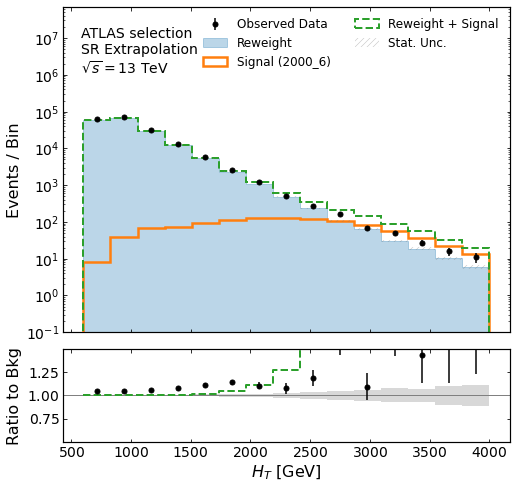

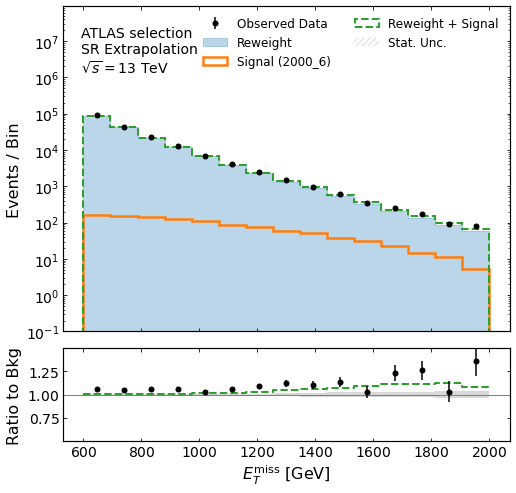

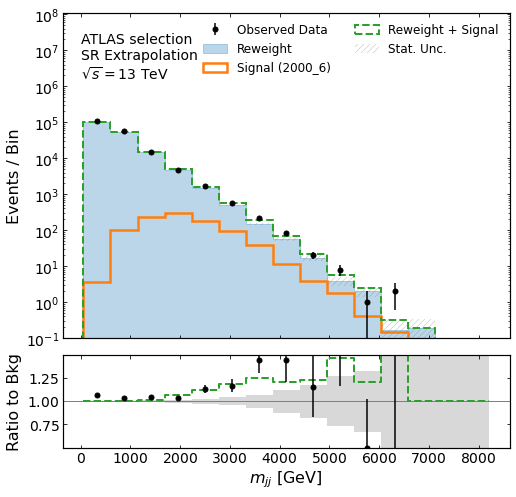

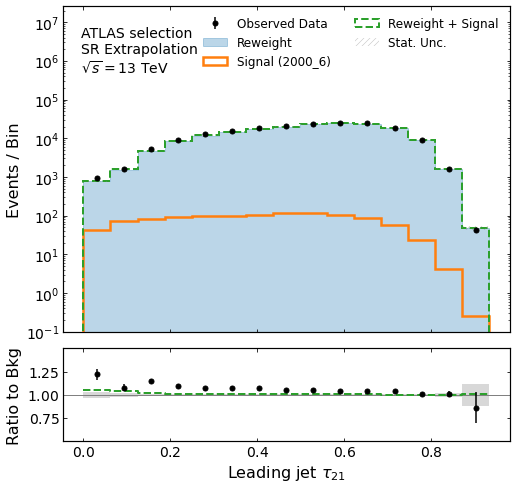

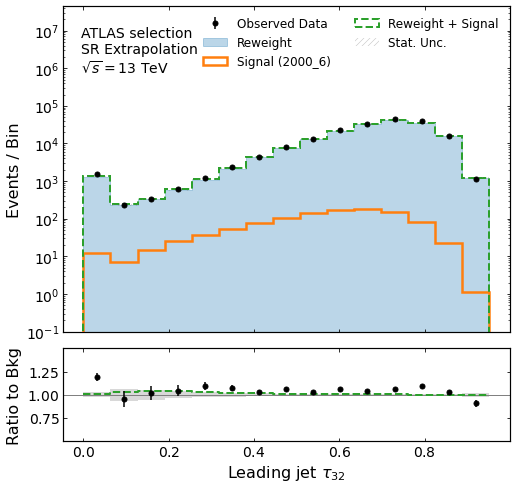

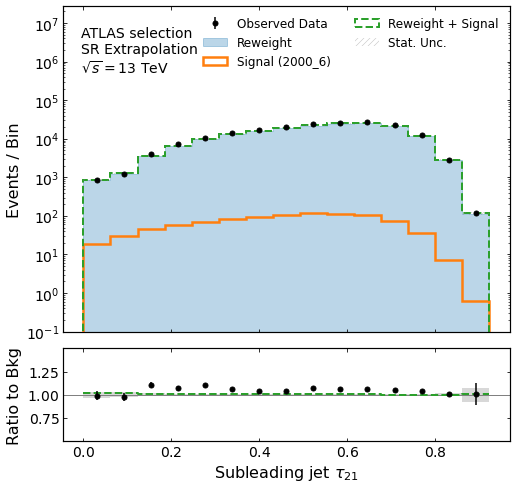

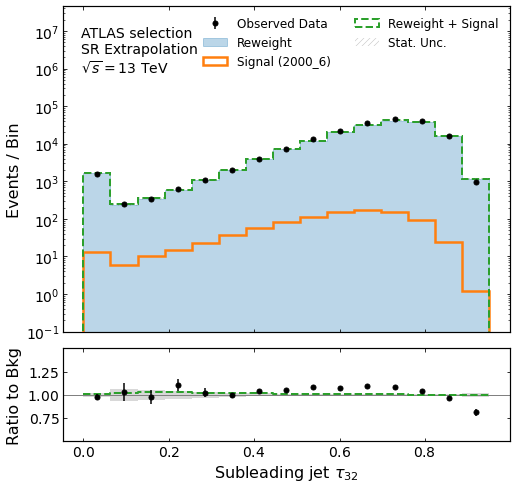

In [ ]:
target_signal_mode = "2000_6"
df_signal = load_signal_for_cwola(target_signal_mode)
print(f"Signal events before SR cuts: {df_signal.height}")

# Apply the EXACT SAME Signal Region cuts used on MC_SR_clean
df_signal = df_signal.filter(
    (pl.col("ht") > 600) &
    (pl.col("met_recalc_pt") > 600) &
    (pl.col("met_recalc_pt") < 2000) & 
    (pl.col("mjj") < 10000) & 
    (pl.col("ht") < 4000)
)

print(f"Signal events after SR cuts: {df_signal.height}")

for var in all_variables_to_plot:
        plot_sr_signal_separated(
        mode_label=selection, 
        df_bkg=df_mc_physical,   # Use physical!
        df_data=df_data_physical, # Use physical!
        df_signal=df_signal,     # Pythia signal is already physical
        feature=var, 
        bkg_label="Reweight", 
        bkg_weight_col="extrapolated_SR_weight",
        signal_label=f"Signal ({target_signal_mode})", 
        force_log=True
    )

In [ ]:
import os
import torch
import joblib
import yaml
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

In [ ]:
X_signal_scaled_full = scaler.transform(df_signal.select(features_to_scale).to_numpy())
X_signal_scaled = X_signal_scaled_full[:, [features_to_scale.index(f) for f in features]]  # Extract only the features used for CWoLa
X_bkg_scaled = df_mc.select(features).to_numpy()  
w_bkg = df_mc.get_column("extrapolated_SR_weight").to_numpy()

In [ ]:
# selection = "ATLAS"
# code_prefix = f"Data_vs_Extrap_{selection}"  # Choose which training you want to evaluate
# eval_dir = f"Eval_CWoLa_SR_{selection}"
# config_path = "/home/aegis/Titan1/NRAD/data/configs/bc_discrim.yml"
# device = "cpu"  # Or "cuda" if using GPU
# classifier_runs = 20

# with open(config_path, 'r') as stream:
#     params = yaml.safe_load(stream)


# # ==========================================
# # 3. RUN INFERENCE OVER ENSEMBLE
# # ==========================================
# print(f"Running inference on {len(X_signal_scaled)} signal events across {classifier_runs} models...")

# # Arrays to hold the scores from all 20 runs
# # Shape: (Number of events, 20)
# all_signal_scores = np.zeros((len(X_signal_scaled), classifier_runs))
# all_bkg_scores = np.zeros((len(X_bkg_scaled), classifier_runs))

# for i in range(classifier_runs):
#     # Initialize a fresh classifier for this run
#     # Construct the path to the saved PyTorch model
#     model_name = f"model_{code_prefix}_run{i}.pt" 
#     model_path = os.path.join(eval_dir, model_name)
    
#     # Load the weights (Adjust this depending on how your Classifier class handles loading)
#     # If your class has a specific load_model method, use that instead.
#     NN = torch.load(model_path, map_location=device)
#     NN.model.eval() # Set to evaluation mode
    
#     # Evaluate Signal
#     scores_sig = NN.evaluation(X_signal_scaled)
#     all_signal_scores[:, i] = scores_sig.flatten()
    
#     # Evaluate Background (for plotting comparison later)
#     scores_bkg = NN.evaluation(X_bkg_scaled)
#     all_bkg_scores[:, i] = scores_bkg.flatten()
    
#     print(f"  -> Processed run {i+1}/{classifier_runs}")

# # ==========================================
# # 4. AGGREGATE SCORES
# # ==========================================
# # Take the median score across the 20 runs for robust predictions
# final_signal_scores = np.median(all_signal_scores, axis=1)
# final_bkg_scores = np.median(all_bkg_scores, axis=1)

# # Add the final scores back into your DataFrame for safekeeping/saving
# df_signal = df_signal.with_columns(pl.Series(name="cwola_score", values=final_signal_scores))
# df_mc = df_mc.with_columns(pl.Series(name="cwola_score", values=final_bkg_scores))

# print("Inference complete!")

import os
import torch
import yaml
import numpy as np
import polars as pl
from sklearn.metrics import roc_curve

# Ensure these are defined from your earlier cells
# X_signal_scaled_full = scaler.transform(df_signal.select(features_to_scale).to_numpy())
# X_signal_scaled = X_signal_scaled_full[:, [features_to_scale.index(f) for f in features]] 
# X_bkg_scaled = df_mc.select(features).to_numpy()  
# w_bkg = df_mc.get_column("extrapolated_SR_weight").to_numpy()

selection = "ATLAS"
code_prefix = f"Data_vs_Extrap_{selection}"  # Choose which training you want to evaluate
eval_dir = f"Eval_CWoLa_SR_{selection}"
config_path = "/home/aegis/Titan1/NRAD/data/configs/bc_discrim.yml"
device = "cpu"  # Or "cuda" if using GPU
classifier_runs = 20

with open(config_path, 'r') as stream:
    params = yaml.safe_load(stream)

# ==========================================
# 3. RUN INFERENCE OVER ENSEMBLE
# ==========================================
# --- NEW: Scale the observed data ---
X_data_scaled = df_data.select(features).to_numpy()

print(f"Running inference across {classifier_runs} models...")

all_signal_scores = np.zeros((len(X_signal_scaled), classifier_runs))
all_bkg_scores = np.zeros((len(X_bkg_scaled), classifier_runs))
all_data_scores = np.zeros((len(X_data_scaled), classifier_runs)) # NEW

for i in range(classifier_runs):
    model_name = f"model_{code_prefix}_run{i}.pt" 
    model_path = os.path.join(eval_dir, model_name)
    
    NN = torch.load(model_path, map_location=device)
    NN.model.eval() 
    
    # Evaluate Signal, Background, and DATA
    all_signal_scores[:, i] = NN.evaluation(X_signal_scaled).flatten()
    all_bkg_scores[:, i] = NN.evaluation(X_bkg_scaled).flatten()
    all_data_scores[:, i] = NN.evaluation(X_data_scaled).flatten() # NEW
    
    print(f"  -> Processed run {i+1}/{classifier_runs}")

# ==========================================
# 4. AGGREGATE SCORES
# ==========================================
final_signal_scores = np.median(all_signal_scores, axis=1)
final_bkg_scores = np.median(all_bkg_scores, axis=1)
final_data_scores = np.median(all_data_scores, axis=1) # NEW

# Add scores to the PHYSICAL dataframes so the mjj axis stays in GeV
df_mc_physical = df_mc_physical.with_columns(pl.Series(name="cwola_score", values=final_bkg_scores))
df_data_physical = df_data_physical.with_columns(pl.Series(name="cwola_score", values=final_data_scores))
df_signal = df_signal.with_columns(pl.Series(name="cwola_score", values=final_signal_scores))

print("Inference complete!")
# ==========================================
# 5. PHYSICS METRICS (ROC, SIC & SIGNIFICANCE)
# ==========================================
print("\nCalculating Physics Discovery Metrics (SIC & ROC)...")

# 1. Extract Signal Weights (Fallback to 1s if column doesn't exist)
if "weight" in df_signal.columns:
    w_sig = df_signal.get_column("weight").to_numpy()
else:
    w_sig = np.ones(len(final_signal_scores))

# --- NEW: CALCULATE INITIAL SIGNIFICANCE ---
total_sig_yield = np.sum(w_sig)*0.2
total_bkg_yield = np.sum(w_bkg)

# Standard HEP naive significance: S / sqrt(B)
initial_significance = total_sig_yield / np.sqrt(total_bkg_yield)
# -------------------------------------------

# 2. Combine labels, scores, and weights
y_true = np.concatenate([np.zeros(len(final_bkg_scores)), np.ones(len(final_signal_scores))])
y_scores = np.concatenate([final_bkg_scores, final_signal_scores])
y_weights = np.concatenate([w_bkg, w_sig])

# 3. Calculate Weighted ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, y_scores, sample_weight=y_weights)

# 4. Filter out zero-FPR to prevent divide-by-zero errors in SIC
valid_idx = np.where(fpr != 0)[0]
fpr_valid = fpr[valid_idx]
tpr_valid = tpr[valid_idx]

# Calculate Rejection and SIC
rejection = 1.0 / fpr_valid 
sic = tpr_valid / np.sqrt(fpr_valid)

# 5. Calculate Max SIC with statistical safety cutoff
# (Using the sum of background weights as the effective number of background events)
n_bkg_eff = np.sum(w_bkg) 
eps_bkg = 1.0 / ((0.4**2) * n_bkg_eff)
safe_indices = np.where(fpr_valid > eps_bkg)[0]

if len(safe_indices) > 0:
    maxsic = np.nanmax(sic[safe_indices])
else:
    maxsic = np.nan

# --- NEW: PROJECTED FINAL SIGNIFICANCE ---
# If maxsic is calculated successfully, apply it to the baseline
projected_final_sig = initial_significance * maxsic if not np.isnan(maxsic) else 0.0
# -----------------------------------------

# 6. Safely find SIC at specific Rejection rates using Interpolation
rejection1_for_sic = 100  # SIC at 100 background rejection
rejection2_for_sic = 1000 # SIC at 1000 background rejection

# Note: Because FPR increases, Rejection decreases. We reverse the arrays [::-1] 
sic_at_rejection1 = np.interp(rejection1_for_sic, rejection[::-1], sic[::-1])
sic_at_rejection2 = np.interp(rejection2_for_sic, rejection[::-1], sic[::-1])

# 7. Print Output
print("\n" + "="*55)
print(" 🎯 PHYSICS DISCOVERY METRICS")
print("="*55)
print(f"Total Background Yield: {total_bkg_yield:,.2f}")
print(f"Total Signal Yield:     {total_sig_yield:,.2f}")
print("-" * 55)
print(f"Initial Significance (S/sqrt(B)): {initial_significance:.4f} σ")
print(f"Max SIC (Multiplier):             {maxsic:.3f}x")
print(f"Projected Final Significance:     {projected_final_sig:.4f} σ")
print("-" * 55)
print(f"SIC @ Background Rejection = 100:  {sic_at_rejection1:.3f}")
print(f"SIC @ Background Rejection = 1000: {sic_at_rejection2:.3f}")
print("="*55 + "\n")

Running inference across 20 models...


/tmp/ipykernel_22651/2699529294.py:99: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  NN = torch.load(model_path, map_location=device)


  -> Processed run 1/20
  -> Processed run 2/20
  -> Processed run 3/20
  -> Processed run 4/20
  -> Processed run 5/20
  -> Processed run 6/20
  -> Processed run 7/20
  -> Processed run 8/20
  -> Processed run 9/20
  -> Processed run 10/20
  -> Processed run 11/20
  -> Processed run 12/20
  -> Processed run 13/20
  -> Processed run 14/20
  -> Processed run 15/20
  -> Processed run 16/20
  -> Processed run 17/20
  -> Processed run 18/20
  -> Processed run 19/20
  -> Processed run 20/20
Inference complete!

Calculating Physics Discovery Metrics (SIC & ROC)...

 🎯 PHYSICS DISCOVERY METRICS
Total Background Yield: 178,290.18
Total Signal Yield:     217.71
-------------------------------------------------------
Initial Significance (S/sqrt(B)): 0.5156 σ
Max SIC (Multiplier):             1.000x
Projected Final Significance:     0.5156 σ
-------------------------------------------------------
SIC @ Background Rejection = 100:  0.017
SIC @ Background Rejection = 1000: 0.013




 📊 CWOLA SCORE STATISTICS

--- Background (Extrapolated) ---
Total Events evaluated: 528846
Mean Score:       0.5011
Median Score:     0.4999
Std Deviation:    0.0186
25th Percentile:  0.4888
75th Percentile:  0.5118
90th Percentile:  0.5252
95th Percentile:  0.5345
99th Percentile:  0.5522

--- Signal ---
Total Events evaluated: 29352
Mean Score:       0.4955
Median Score:     0.4932
Std Deviation:    0.0207
25th Percentile:  0.4805
75th Percentile:  0.5069
90th Percentile:  0.5284
95th Percentile:  0.5349
99th Percentile:  0.5390

--------------------------------------------------
 🎯 QUICK PERFORMANCE METRIC
--------------------------------------------------
Score threshold to keep top 5% of Background: > 0.5345
Signal Efficiency at this threshold:          5.34%



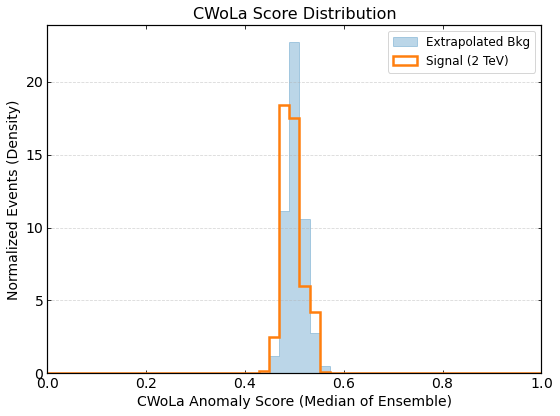

In [ ]:
def plot_cwola_scores(bkg_scores, bkg_weights, sig_scores, sig_label):
    plt.figure(figsize=(8, 6))
    
    # Define binning for scores (0 to 1)
    bins = np.linspace(0, 1, 50)
    
    # Plot Background
    plt.hist(bkg_scores, bins=bins, weights=bkg_weights, 
             density=True, histtype='stepfilled', alpha=0.3, color='#1f78b4', 
             label='Extrapolated Bkg', edgecolor='#1f78b4')
    
    # Plot Signal (Unweighted to show pure ML shape, or weighted if you prefer)
    plt.hist(sig_scores, bins=bins, 
             density=True, histtype='step', linewidth=2.5, color='#ff7f0e', 
             label=sig_label)
             
    plt.xlabel("CWoLa Anomaly Score (Median of Ensemble)", fontsize=14)
    plt.ylabel("Normalized Events (Density)", fontsize=14)
    plt.title("CWoLa Score Distribution", fontsize=16)
    plt.xlim(0, 1)
    plt.legend(fontsize=12, loc='upper right')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

def print_cwola_statistics(bkg_scores, sig_scores):
    print("\n" + "="*50)
    print(" 📊 CWOLA SCORE STATISTICS")
    print("="*50)

    # Dictionary to iterate over both sets
    datasets = {
        "Background (Extrapolated)": bkg_scores,
        "Signal": sig_scores
    }

    for name, scores in datasets.items():
        print(f"\n--- {name} ---")
        print(f"Total Events evaluated: {len(scores)}")
        print(f"Mean Score:       {np.mean(scores):.4f}")
        print(f"Median Score:     {np.median(scores):.4f}")
        print(f"Std Deviation:    {np.std(scores):.4f}")
        print(f"25th Percentile:  {np.percentile(scores, 25):.4f}")
        print(f"75th Percentile:  {np.percentile(scores, 75):.4f}")
        print(f"90th Percentile:  {np.percentile(scores, 90):.4f}")
        print(f"95th Percentile:  {np.percentile(scores, 95):.4f}")
        print(f"99th Percentile:  {np.percentile(scores, 99):.4f}")

    # Calculate a quick physics performance metric
    # Let's find the cut threshold that rejects 95% of the background
    cut_95 = np.percentile(bkg_scores, 95)
    
    # See how much signal survives that strict cut
    sig_surviving = np.sum(sig_scores > cut_95)
    sig_eff = sig_surviving / len(sig_scores)
    
    print("\n" + "-"*50)
    print(" 🎯 QUICK PERFORMANCE METRIC")
    print("-"*50)
    print(f"Score threshold to keep top 5% of Background: > {cut_95:.4f}")
    print(f"Signal Efficiency at this threshold:          {sig_eff * 100:.2f}%")
    print("="*50 + "\n")

# Call the function using your existing arrays
print_cwola_statistics(final_bkg_scores, final_signal_scores)

# Call the function
plot_cwola_scores(
    bkg_scores=final_bkg_scores, 
    bkg_weights=w_bkg, 
    sig_scores=final_signal_scores, 
    sig_label="Signal (2 TeV)"
)

In [ ]:
# ==============================================================================
# 4. EXTRACT HISTOGRAMS FOR LIMIT SETTING
# ==============================================================================
# Define the cut (e.g., 95th percentile of background = keep top 5%)
cut_threshold = np.percentile(final_bkg_scores, 95)
print(f"\nApplying strict CWoLa cut: score > {cut_threshold:.4f}")

pass_bkg  = df_mc_physical.filter(pl.col("cwola_score") > cut_threshold)
pass_data = df_data_physical.filter(pl.col("cwola_score") > cut_threshold)
pass_sig  = df_signal.filter(pl.col("cwola_score") > cut_threshold)

mjj_bins = np.linspace(1000, 4000, 31)

hist_bkg, _ = np.histogram(
    pass_bkg.get_column("mjj").to_numpy(), bins=mjj_bins, 
    weights=pass_bkg.get_column("extrapolated_SR_weight").to_numpy()
)
hist_data, _ = np.histogram(
    pass_data.get_column("mjj").to_numpy(), bins=mjj_bins
)
hist_sig, _ = np.histogram(
    pass_sig.get_column("mjj").to_numpy(), bins=mjj_bins, 
    weights=pass_sig.get_column("weight").to_numpy()
)
hist_bkg_var, _ = np.histogram(
    pass_bkg.get_column("mjj").to_numpy(), bins=mjj_bins, 
    weights=pass_bkg.get_column("extrapolated_SR_weight").to_numpy()**2
)


# ==============================================================================
# 5. PYHF LIMIT CALCULATION (GRID SCAN)
# ==============================================================================
print("\n" + "="*50)
print(" 📈 CALCULATING 95% CL LIMITS WITH PYHF")
print("="*50)

# Epsilon Trick for Empty Bins
epsilon = 1e-6
hist_bkg_safe = np.where(hist_bkg <= 0, epsilon, hist_bkg)
hist_bkg_var_safe = np.where(hist_bkg_var <= 0, epsilon, hist_bkg_var)

bkg_counts = hist_bkg_safe.tolist()
bkg_errors = np.sqrt(hist_bkg_var_safe).tolist()
sig_counts = np.clip(hist_sig, 0, None).tolist()
data_counts = np.clip(hist_data, 0, None).tolist()

model_spec = {
    "channels": [{"name": "SR_mjj", "samples": [
        {"name": "Background", "data": bkg_counts, "modifiers": [{"name": "stat_uncert", "type": "staterror", "data": bkg_errors}]},
        {"name": "Signal", "data": sig_counts, "modifiers": [{"name": "mu", "type": "normfactor", "data": None}]}
    ]}],
    "observations": [{"name": "SR_mjj", "data": data_counts}],
    "measurements": [{"name": "Limit", "config": {"poi": "mu", "parameters": [{"name": "mu", "bounds": [[0.0, 50.0]]}]}}],
    "version": "1.0.0"
}

workspace = pyhf.Workspace(model_spec)
model = workspace.model()
data_ws = workspace.data(model)

print("Running CLs frequentist grid scan...")
mu_scan = np.linspace(0.01, 15.0, 100) # Increased the ceiling to 15.0

obs_cls_list, exp_cls_list = [], []
for mu in mu_scan:
    obs, exp = pyhf.infer.hypotest(float(mu), data_ws, model, test_stat="qtilde", return_expected_set=True)
    obs_cls_list.append(obs)
    exp_cls_list.append(exp)

obs_cls = np.array(obs_cls_list)
exp_cls_set = np.array(exp_cls_list).T

def find_limit(scan_values, cls_values, threshold=0.05):
    cls_vals_flat = np.array([float(val) for val in cls_values])
    return np.interp(threshold, cls_vals_flat[::-1], scan_values[::-1])

obs_limit = find_limit(mu_scan, obs_cls)
exp_m2  = find_limit(mu_scan, exp_cls_set[0])
exp_m1  = find_limit(mu_scan, exp_cls_set[1])
exp_med = find_limit(mu_scan, exp_cls_set[2])
exp_p1  = find_limit(mu_scan, exp_cls_set[3])
exp_p2  = find_limit(mu_scan, exp_cls_set[4])

print("\n--- Final Limit Results (Signal Strength μ) ---")
print(f"Observed Limit:      {obs_limit:.3f}")
print(f"Expected Limit:      {exp_med:.3f}")
print(f"  Expected +1 sigma: {exp_p1:.3f}")
print(f"  Expected -1 sigma: {exp_m1:.3f}")
print(f"  Expected +2 sigma: {exp_p2:.3f}")
print(f"  Expected -2 sigma: {exp_m2:.3f}")
print("==================================================")


Applying strict CWoLa cut: score > 0.5345

 📈 CALCULATING 95% CL LIMITS WITH PYHF
Running CLs frequentist grid scan...

--- Final Limit Results (Signal Strength μ) ---
Observed Limit:      5.741
Expected Limit:      4.943
  Expected +1 sigma: 7.227
  Expected -1 sigma: 3.371
  Expected +2 sigma: 10.113
  Expected -2 sigma: 2.372
